# Week 08 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('../src')

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore', message='R.*score is not well-defined')

# Colorblind-safe palette (Wong)
COLORS = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#F0E442']

In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y

## Function 1

In [3]:
# Cell A — Setup + data overview
N = 1
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4e} | Y range [{Y.min():.3e}, {Y.max():.3e}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

print("\nSorted by Y (W7 marked ★):")
order = np.argsort(-Y)
labels = ['init']*10 + [f'W{w}' for w in range(1, 8)]
for rank, idx in enumerate(order):
    star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}) Y={Y[idx]:+.3e}  [{labels[idx]:>4}]{star}")
print(f"\nCounts: positives={int((Y>0).sum())} | negatives={int((Y<0).sum())}")


Function 1: 17 points, 2D, best y = 0.0000
F1: 17 pts, 2D | baseline RMSE = 1.7281e-03 | Y range [-6.627e-03, 3.651e-07]
Per-dim correlations: r(x1,Y)=+0.058, r(x2,Y)=-0.026

Sorted by Y (W7 marked ★):
   1. (0.7002, 0.6954) Y=+3.651e-07  [  W3]
   2. (0.7310, 0.7330) Y=+7.711e-16  [init]
   3. (0.6654, 0.4374) Y=+1.894e-28  [  W4]
   4. (0.7800, 0.7800) Y=+2.500e-32  [  W2]
   5. (0.6834, 0.8611) Y=+2.535e-40  [init]
   6. (0.2287, 0.5658) Y=+6.244e-42  [  W5]
   7. (0.5743, 0.8799) Y=+1.033e-46  [init]
   8. (0.8839, 0.5823) Y=+6.230e-48  [init]
   9. (0.3194, 0.7630) Y=+1.323e-79  [init]
  10. (0.0825, 0.4035) Y=+3.607e-81  [init]
  11. (0.8404, 0.2647) Y=+3.342e-124  [init]
  12. (0.3127, 0.0787) Y=-2.089e-91  [init]
  13. (0.6172, 0.2223) Y=-1.809e-57  [  W6]
  14. (0.4104, 0.1476) Y=-2.159e-54  [init]
  15. (0.2736, 0.3090) Y=-2.075e-25  [  W7] ★
  16. (0.6501, 0.6815) Y=-3.606e-03  [init]
  17. (0.4211, 0.4636) Y=-6.627e-03  [  W1]

Counts: positives=11 | negatives=6


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/3354210691.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/3354210691.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])


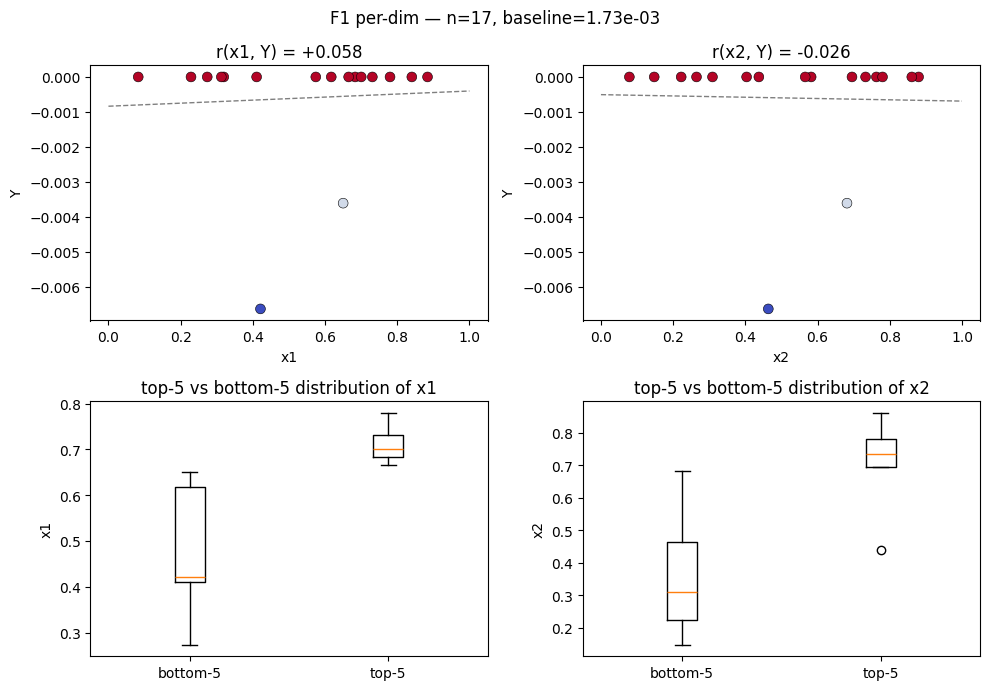

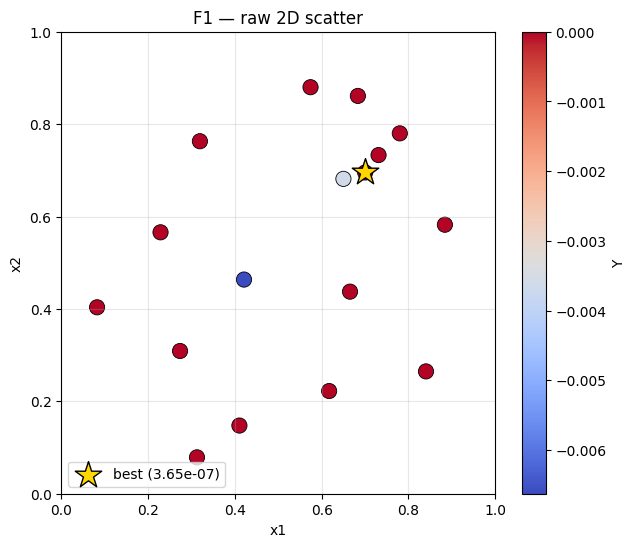

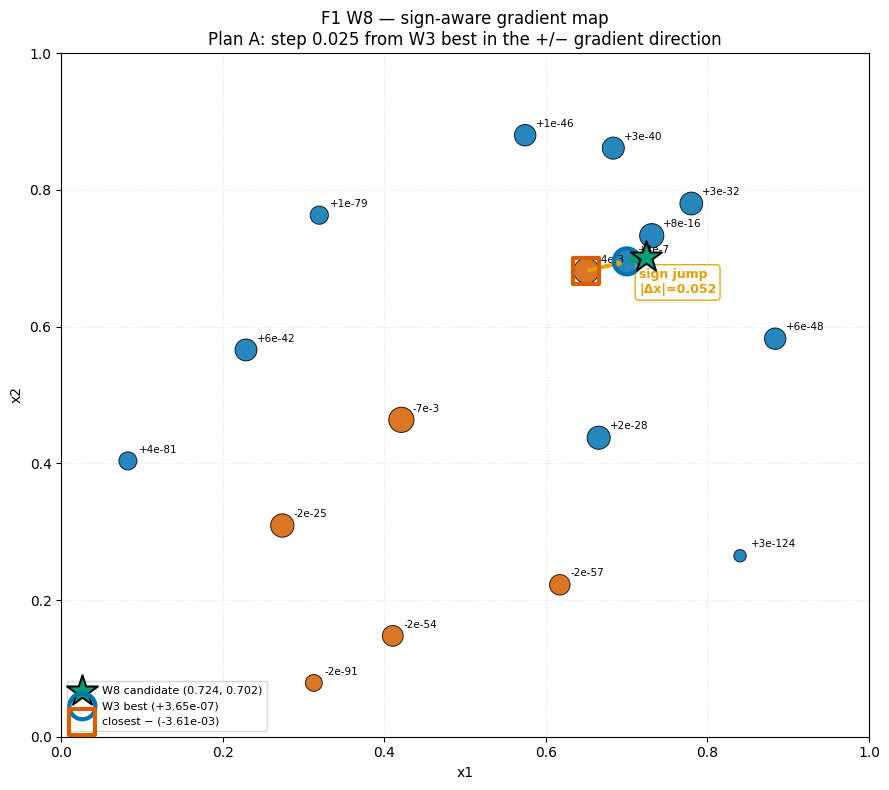


P_neg = [0.65011406 0.68152635], P_pos = [0.700201 0.695377]
Candidate = [0.72429667 0.70204023]  (step from W3 best: [0.02409567 0.00666323])


In [4]:
# Cell B — Per-dim scatter + 2D scatter + sign-aware gradient map
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import os
os.makedirs('../plots/week_08', exist_ok=True)

# B1: per-dim scatter + boxplots (standard /analyze format)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i in range(2):
    sc = axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1)
    xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(X[:, i], Y)[0, 1]
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {r:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(2):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
    axes[1, i].set(ylabel=f'x{i+1}', title=f'top-5 vs bottom-5 distribution of x{i+1}')
plt.suptitle(f'F1 per-dim — n={len(Y)}, baseline={baseline:.2e}')
plt.tight_layout()
plt.savefig('../plots/week_08/function_1_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# B2: 2D scatter coloured by Y
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sc = ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=120, edgecolors='k', linewidths=0.6)
plt.colorbar(sc, ax=ax, label='Y')
ax.scatter(X[Y.argmax(), 0], X[Y.argmax(), 1], marker='*', s=400, facecolor='gold', edgecolor='black', linewidths=1, zorder=5, label=f'best ({Y.max():.2e})')
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='x1', ylabel='x2', title='F1 — raw 2D scatter')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_08/function_1_2d_scatter.png', dpi=110, bbox_inches='tight')
plt.show()

# B3: sign-aware gradient map (the F1 W8 deliberate-deviation diagnostic)
i_best = int(Y.argmax()); P_pos = X[i_best]; y_pos = Y[i_best]
neg_idx = np.where(Y < 0)[0]
i_closest_neg = neg_idx[int(cdist(P_pos.reshape(1, -1), X[neg_idx])[0].argmin())]
P_neg = X[i_closest_neg]; y_neg = Y[i_closest_neg]
gradient_dir = P_pos - P_neg
gradient_norm = float(np.linalg.norm(gradient_dir))

step_size = 0.025
candidate_gradient = np.clip(P_pos + step_size * gradient_dir / gradient_norm, 0.001, 0.999)

mag = np.log10(np.abs(Y) + 1e-200)
sizes = 80 + 250 * (mag - mag.min()) / (mag.max() - mag.min() + 1e-12)
colors_pn = np.where(Y > 0, COLORS[0], COLORS[1])

fig, ax = plt.subplots(1, 1, figsize=(9, 8))
ax.scatter(X[:, 0], X[:, 1], c=colors_pn, s=sizes, edgecolors='k', linewidths=0.7, alpha=0.85, zorder=3)
for i, (xi, yi) in enumerate(X):
    sci = f'{Y[i]:+.0e}'.replace('e+0', 'e+').replace('e-0', 'e-')
    ax.annotate(sci, (xi, yi), xytext=(8, 6), textcoords='offset points', fontsize=7.5)
ax.annotate('', xy=P_pos, xytext=P_neg, arrowprops=dict(arrowstyle='->', color=COLORS[3], lw=3, alpha=0.95))
midx, midy = (P_pos[0]+P_neg[0])/2, (P_pos[1]+P_neg[1])/2
ax.text(midx + 0.04, midy - 0.04, f'sign jump\n|Δx|={gradient_norm:.3f}', fontsize=9, color=COLORS[3], fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS[3], alpha=0.9))
ax.annotate('', xy=candidate_gradient, xytext=P_pos,
            arrowprops=dict(arrowstyle='->', color=COLORS[2], lw=3, alpha=0.95, linestyle='--'))
ax.scatter([candidate_gradient[0]], [candidate_gradient[1]], marker='*', s=550, color=COLORS[2], edgecolors='black', linewidths=1.4, zorder=5, label=f'W8 candidate ({candidate_gradient[0]:.3f}, {candidate_gradient[1]:.3f})')
ax.scatter([P_pos[0]], [P_pos[1]], marker='o', s=350, facecolor='none', edgecolors=COLORS[0], linewidths=3, zorder=4, label=f'W3 best (+{y_pos:.2e})')
ax.scatter([P_neg[0]], [P_neg[1]], marker='s', s=350, facecolor='none', edgecolors=COLORS[1], linewidths=3, zorder=4, label=f'closest − ({y_neg:.2e})')
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='x1', ylabel='x2', title='F1 W8 — sign-aware gradient map\nPlan A: step 0.025 from W3 best in the +/− gradient direction')
ax.legend(loc='lower left', fontsize=8); ax.grid(alpha=0.3, linestyle=':')
plt.tight_layout()
plt.savefig('../plots/week_08/function_1_gradient_map.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'\nP_neg = {P_neg}, P_pos = {P_pos}')
print(f'Candidate = {candidate_gradient}  (step from W3 best: {candidate_gradient - P_pos})')


In [5]:
# Cell C — Feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_)
lin_norm = lin_coef / (lin_coef.sum() + 1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])

print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'Linear':>8}  {'|corr|':>7}  flag")
for d in range(X.shape[1]):
    drop = (rf_all[d] - rf_no[d]) / (rf_all[d] + 1e-12) * 100 if rf_all[d] > 0 else 0
    flag = '⚠ inflated' if drop > 50 else ''
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no[d]:>13.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}  {flag}")


 Dim   RF (all)   RF (no best)    Linear   |corr|  flag
  x1      0.485          0.454     0.611    0.058  
  x2      0.515          0.546     0.389    0.026  


In [6]:
# Cell D — Model grid search (LOOCV RMSE) — F1 historically: nothing beats baseline
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm

cv = LeaveOneOut()

def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1)
    gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_, gs.best_params_

results = []
results.append(fit_grid('Ridge',    Ridge(),                                {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN',      KNeighborsRegressor(),                  {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF',       RandomForestRegressor(random_state=0),  {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR',      SVR(kernel='rbf'),                      {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB',       GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))

# GP variants — fit once each (no GridSearchCV)
for name, kernel in [
    ('GP-Matern05', ConstantKernel() * Matern(length_scale=0.3, nu=0.5)),
    ('GP-Matern15', ConstantKernel() * Matern(length_scale=0.3, nu=1.5)),
    ('GP-Matern25', ConstantKernel() * Matern(length_scale=0.3, nu=2.5)),
    ('GP-RBF',      ConstantKernel() * RBF(length_scale=0.3)),
]:
    try:
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
        score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
        results.append((name, score, gp.fit(X, Y), kernel))
    except Exception as e:
        print(f'  {name}: failed ({e})')

# NN
try:
    nn_est, nn_meta = nm.load_nn(N, models_dir='../models/week_08')
    nn_rmse = nn_meta['cv_rmse']
    results.append(('NN', nn_rmse, nn_est, nn_meta))
except Exception as e:
    print(f'  NN: load failed ({e})')

print(f"\n{'Model':>14}  {'RMSE':>10}  {'baseline':>10}  beats?")
print('-' * 50)
beats_models = {}
for r in results:
    name, rmse = r[0], r[1]
    beat = rmse < baseline
    if beat: beats_models[name] = (r[2], rmse)
    print(f"  {name:>12}  {rmse:>10.4e}  {baseline:>10.4e}  {'✓' if beat else '✗'}")
print(f"\nModels beating baseline: {len(beats_models)} / {len(results)}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v


         Model        RMSE    baseline  beats?
--------------------------------------------------
         Ridge  1.1296e-03  1.7281e-03  ✓
           KNN  1.0724e-03  1.7281e-03  ✓
            RF  1.4676e-03  1.7281e-03  ✓
           SVR  3.2247e-03  1.7281e-03  ✗
            GB  1.2355e-03  1.7281e-03  ✓
   GP-Matern05  1.1480e-03  1.7281e-03  ✓
   GP-Matern15  1.1882e-03  1.7281e-03  ✓
   GP-Matern25  1.2025e-03  1.7281e-03  ✓
        GP-RBF  1.1287e-03  1.7281e-03  ✓
            NN  2.7701e-03  1.7281e-03  ✗

Models beating baseline: 8 / 10


In [7]:
# Cell E — Model argmax suggestions + consensus check (F1 W8: 8/10 models beat baseline)
rng = np.random.default_rng(0)
cand = rng.uniform(size=(200_000, 2))

print(f"{'Model':>14}  {'sugg x1':>8}  {'sugg x2':>8}  {'pred Y':>12}  boundary?")
print('-' * 65)
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand)
    i = int(yhat.argmax())
    pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    flag = '⚠ BOUNDARY' if on_b else ''
    print(f"  {name:>12}  {pt[0]:>8.4f}  {pt[1]:>8.4f}  {yhat[i]:>12.4e}  {flag}")

print(f"\nBoundary-consensus check (excluding Ridge):")
for d in range(2):
    low_count = sum(1 for n, s in suggestions.items() if n != 'Ridge' and s['x'][d] < 0.02)
    high_count = sum(1 for n, s in suggestions.items() if n != 'Ridge' and s['x'][d] > 0.98)
    corr_d = np.corrcoef(X[:, d], Y)[0, 1]
    print(f"  x{d+1}: {low_count} models on low-edge, {high_count} on high-edge, corr={corr_d:+.3f}")

# Filter Ridge + boundary
valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
print(f"\nValid interior, non-Ridge suggestions: {len(valid)}")

# Crucial F1-specific filter: drop models whose predicted "max" is itself negative
# (they're tracking the negative valley, not the maximum)
maxima_seekers = {n: s for n, s in valid.items() if s['y_hat'] > 0}
valley_trackers = {n: s for n, s in valid.items() if s['y_hat'] <= 0}

print(f"\nMaxima-seeker models (predict Y > 0 at their argmax):  {list(maxima_seekers.keys())}")
print(f"Valley-tracker models (predict Y ≤ 0 at their argmax):   {list(valley_trackers.keys())}")
print("→ Only maxima-seekers are useful for finding F1's positive zone.")

if maxima_seekers:
    pts_maxima = np.array([s['x'] for s in maxima_seekers.values()])
    weights = 1 / np.array([s['rmse'] for s in maxima_seekers.values()])
    weights /= weights.sum()
    ens_maxima = (weights[:, None] * pts_maxima).sum(axis=0)
    print(f"Maxima-seeker ensemble argmax: ({ens_maxima[0]:.4f}, {ens_maxima[1]:.4f})")
    
    # Compare to plan A candidate
    dist_to_plan_a = np.linalg.norm(ens_maxima - candidate_gradient)
    print(f"Distance from plan A candidate: {dist_to_plan_a:.4f}")


         Model   sugg x1   sugg x2        pred Y  boundary?
-----------------------------------------------------------------
         Ridge    0.9993    0.0046   -5.9919e-04  ⚠ BOUNDARY
           KNN    0.6997    0.6965    3.5581e-07  


            RF    0.0410    0.0165   -3.6819e-06  ⚠ BOUNDARY
            GB    0.8765    0.0586   -3.3726e-04  
   GP-Matern05    0.5746    0.8802   -6.0195e-04  
   GP-Matern15    0.6370    0.2698   -6.0195e-04  
   GP-Matern25    0.6370    0.2698   -6.0195e-04  
        GP-RBF    0.6370    0.2698   -6.0195e-04  

Boundary-consensus check (excluding Ridge):
  x1: 0 models on low-edge, 0 on high-edge, corr=+0.058
  x2: 1 models on low-edge, 0 on high-edge, corr=-0.026

Valid interior, non-Ridge suggestions: 6

Maxima-seeker models (predict Y > 0 at their argmax):  ['KNN']
Valley-tracker models (predict Y ≤ 0 at their argmax):   ['GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'GP-RBF']
→ Only maxima-seekers are useful for finding F1's positive zone.
Maxima-seeker ensemble argmax: (0.6997, 0.6965)
Distance from plan A candidate: 0.0252


In [8]:
# Cell F — F1-specific: SVC sign classifier + log-SVR
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV, LeaveOneOut

sign_y = (Y > 0).astype(int)
print(f"Sign distribution: pos={sign_y.sum()}, neg/zero={(1-sign_y).sum()}")

# SVC grid (per CLAUDE.md F1 strategy: SVM C=10 baseline, also test C=1 and C=100)
clf_grid = GridSearchCV(SVC(kernel='rbf', gamma='scale'), {'C': [1, 10, 100]},
                        scoring='accuracy', cv=LeaveOneOut(), n_jobs=1)
clf_grid.fit(X, sign_y)
clf_loo_acc = clf_grid.best_score_
print(f"SVC sign classifier: best C={clf_grid.best_params_['C']}, LOO accuracy = {clf_loo_acc:.2%}")
print(f"  85% trust gate: {'✓ FIRES' if clf_loo_acc >= 0.85 else f'✗ below gate by {(0.85 - clf_loo_acc)*100:+.1f}pp'}")

# log-SVR on log10(|Y|+1e-200)
log_abs_Y = np.log10(np.abs(Y) + 1e-200)
log_svr = GridSearchCV(SVR(kernel='rbf'), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
                       scoring='neg_root_mean_squared_error', cv=LeaveOneOut(), n_jobs=1)
log_svr.fit(X, log_abs_Y)
log_svr_rmse = -log_svr.best_score_
log_svr_baseline = log_abs_Y.std()
print(f"log-SVR on log10|Y|: RMSE={log_svr_rmse:.3f} vs baseline {log_svr_baseline:.3f}  "
      f"({'✓' if log_svr_rmse < log_svr_baseline else '✗'})")

# Combined approach (informational; we are NOT trusting it this week because classifier is below gate)
g = 100
gx, gy = np.meshgrid(np.linspace(0, 1, g), np.linspace(0, 1, g))
grid = np.column_stack([gx.ravel(), gy.ravel()])
p_pos = clf_grid.predict(grid)  # 0 or 1 (SVC doesn't return probabilities by default)
log_pred = log_svr.predict(grid)
combined = p_pos * (log_pred - log_pred.min()) / (log_pred.max() - log_pred.min() + 1e-12)
combined_argmax = grid[combined.argmax()]
print(f"Combined-score argmax: ({combined_argmax[0]:.3f}, {combined_argmax[1]:.3f}) — informational only (classifier below 85%)")


Sign distribution: pos=11, neg/zero=6
SVC sign classifier: best C=10, LOO accuracy = 82.35%
  85% trust gate: ✗ below gate by +2.6pp
log-SVR on log10|Y|: RMSE=13.604 vs baseline 32.383  (✓)
Combined-score argmax: (0.606, 0.596) — informational only (classifier below 85%)


### F1 — Decision

**Query: `next_query_1 = candidate_gradient` → (0.724297, 0.702040)**

Method: **manual gradient-climb, validated by KNN agreement** (Branch 5: strong-but-disagreeing — single model trusted on the maxima-search question).

Why: A meaningful change happened this week — 8 of 10 models beat baseline for F1 for the first time. But the agreement is shallow:
- **KNN** suggests (0.6997, 0.6965) predicting Y=+3.56e-7 — essentially "return to W3 best." This validates plan A.
- **3 GPs + GB** suggest (0.637, 0.270) or (0.575, 0.880) predicting Y=−6e-4. They've found the *least negative* point in the dataset — they're modelling the negative valley structure, not the positive maximum. Their predicted "max" is more negative than the W3 best, so they fail the F1-specific maxima-seeker filter.
- **Ridge** pushes to a corner (0.999, 0.005) — standard linear extrapolation artifact.

Plan A's candidate (0.724, 0.702) is 0.025 from KNN's suggestion in the +/− gradient direction. KNN says "go to the only known positive"; plan A refines that with "go just past it, in the direction the +/− jump tells us positives lie."

The classifier rose to 82.35% LOO (W7→W8: 81% → 82%) — still 2.6pp below the 85% trust gate, so the combined classifier+log-SVR path stays closed for one more week.

Branch of decision tree (from Step 5):
- [ ] 1. No models beat baseline (was true W1-W7; no longer)
- [ ] 2-4 (not used)
- [x] 5. Strong but disagreeing → trust KNN on the maxima-search question (only positive-predicting model), refine with +/− gradient direction
- [ ] 6. TuRBO (not used; plan A is the deviation)

Per-dimension justification:
- x1: P_pos.x1 + step × Δx1/|Δ| = 0.700 + 0.024 = 0.724  (KNN suggests 0.700; plan A nudges +0.024)
- x2: P_pos.x2 + step × Δx2/|Δ| = 0.695 + 0.007 = 0.702  (KNN suggests 0.697; plan A nudges +0.005)

W9 contingency:
- If Y > +3.65e-7: real gradient. Step 0.030-0.040 in same direction. Continue exploiting.
- If Y ∈ [0, +3.65e-7]: plateau. Try perpendicular step or use the maxima-seeker ensemble argmax.
- If Y < 0: positive island is tiny. Halve step toward W3 best, or pivot to maxima-seeker ensemble.
- If classifier crosses 85%: the combined classifier+log-SVR path opens — re-evaluate F1's long-term strategy.


In [9]:
# Cell I — next_query_1 assignment
next_query_1 = candidate_gradient.copy()
print(f"F1 query: {next_query_1[0]:.6f}, {next_query_1[1]:.6f}")
print(f"  step from W3 best (0.7002, 0.6954): ({next_query_1[0]-0.7002:+.4f}, {next_query_1[1]-0.6954:+.4f})")


F1 query: 0.724297, 0.702040
  step from W3 best (0.7002, 0.6954): (+0.0241, +0.0066)


## Function 2

In [10]:
# Cell A — F2 setup + data overview
N = 2
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

print("\nTop 8 sorted by Y (W7 marked ★):")
order = np.argsort(-Y)
labels = ['init']*10 + [f'W{w}' for w in range(1, 8)]
for rank in range(min(8, len(order))):
    idx = int(order[rank])
    star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

print("\nWeekly trajectory:")
for w in range(1, 8):
    idx = 10 + w - 1
    print(f"  W{w}: ({X[idx,0]:.4f}, {X[idx,1]:.4f}) → Y={Y[idx]:+.4f}")


Function 2: 17 points, 2D, best y = 0.6961
F2: 17 pts, 2D | baseline RMSE = 0.2442 | Y range [-0.0656, 0.6961]
Per-dim corr: r(x1,Y)=+0.580, r(x2,Y)=+0.668

Top 8 sorted by Y (W7 marked ★):
   1. (0.7036, 0.9469) Y=+0.6961  [  W6]
   2. (0.7019, 0.9533) Y=+0.6658  [  W3]
   3. (0.7026, 0.9266) Y=+0.6112  [init]
   4. (0.7031, 0.9438) Y=+0.5756  [  W7] ★
   5. (0.6658, 0.1240) Y=+0.5390  [init]
   6. (0.6939, 0.9626) Y=+0.4995  [  W5]
   7. (0.7500, 0.9200) Y=+0.4265  [  W2]
   8. (0.8778, 0.7786) Y=+0.4206  [init]

Weekly trajectory:
  W1: (0.7540, 0.5253) → Y=+0.2813
  W2: (0.7500, 0.9200) → Y=+0.4265
  W3: (0.7019, 0.9533) → Y=+0.6658
  W4: (0.8958, 0.1240) → Y=+0.0852
  W5: (0.6939, 0.9626) → Y=+0.4995
  W6: (0.7036, 0.9469) → Y=+0.6961
  W7: (0.7031, 0.9438) → Y=+0.5756


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/654821490.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/654821490.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])


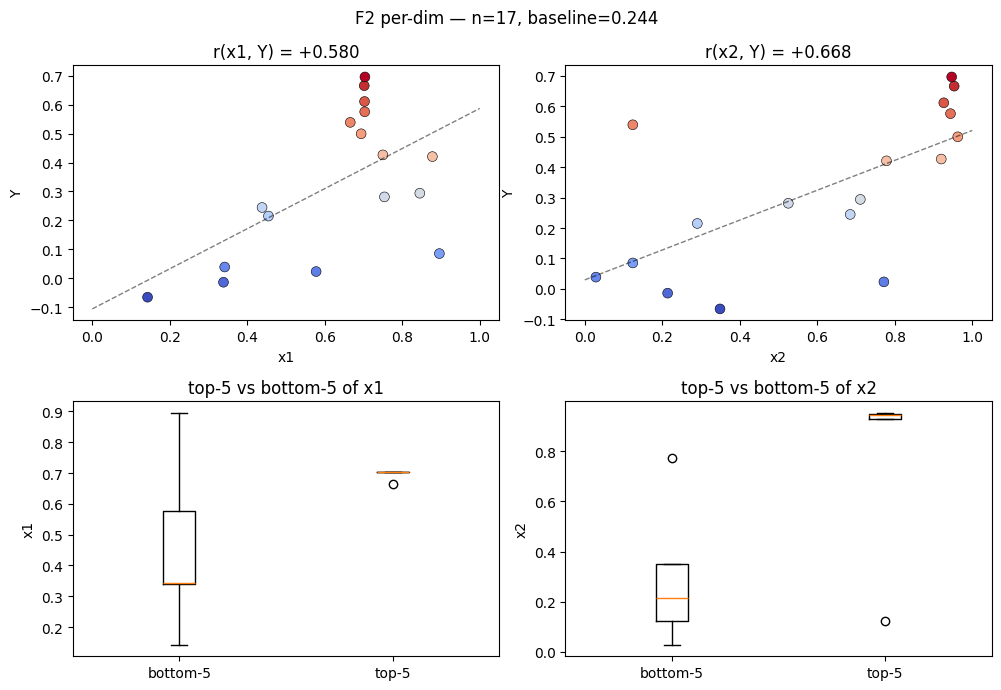

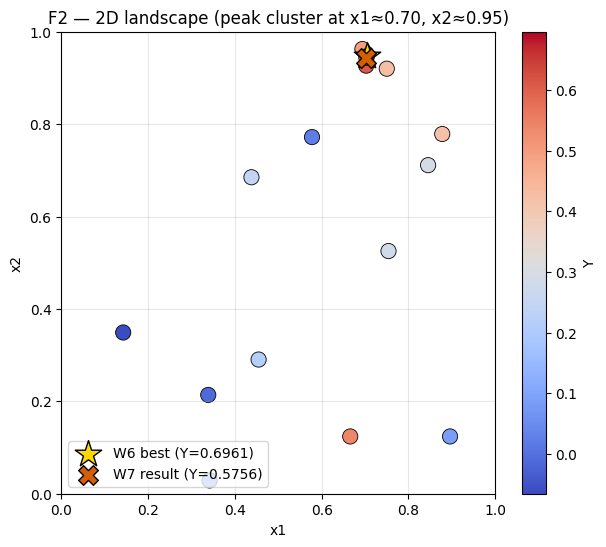

In [11]:
# Cell B — F2 per-dim + 2D scatter
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_08', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i in range(2):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1)
    xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(X[:, i], Y)[0, 1]
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {r:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(2):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
    axes[1, i].set(ylabel=f'x{i+1}', title=f'top-5 vs bottom-5 of x{i+1}')
plt.suptitle(f'F2 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout()
plt.savefig('../plots/week_08/function_2_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# 2D scatter
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sc = ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=120, edgecolors='k', linewidths=0.6)
plt.colorbar(sc, ax=ax, label='Y')
i_best = int(Y.argmax())
ax.scatter(X[i_best, 0], X[i_best, 1], marker='*', s=400, facecolor='gold', edgecolor='black', linewidths=1, zorder=5, label=f'W6 best (Y={Y[i_best]:.4f})')
# W7 marker
ax.scatter(X[-1, 0], X[-1, 1], marker='X', s=200, facecolor=COLORS[1], edgecolor='black', linewidths=1, zorder=5, label=f'W7 result (Y={Y[-1]:.4f})')
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='x1', ylabel='x2', title='F2 — 2D landscape (peak cluster at x1≈0.70, x2≈0.95)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_08/function_2_2d_scatter.png', dpi=110, bbox_inches='tight')
plt.show()


In [12]:
# Cell C — F2 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_)
lin_norm = lin_coef / (lin_coef.sum() + 1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])

print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'Linear':>8}  {'|corr|':>7}  flag")
for d in range(X.shape[1]):
    drop = (rf_all[d] - rf_no[d]) / (rf_all[d] + 1e-12) * 100 if rf_all[d] > 0 else 0
    flag = '⚠ inflated' if drop > 50 else ''
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no[d]:>13.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}  {flag}")


 Dim   RF (all)   RF (no best)    Linear   |corr|  flag
  x1      0.500          0.488     0.531    0.580  
  x2      0.500          0.512     0.469    0.668  


In [13]:
# Cell D — F2 model grid search
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm

cv = LeaveOneOut()

def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1)
    gs.fit(X, Y); return name, -gs.best_score_, gs.best_estimator_

results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN',   KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF',    RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR',   SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB',    GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kernel in [
    ('GP-Matern05', ConstantKernel() * Matern(length_scale=0.3, nu=0.5)),
    ('GP-Matern15', ConstantKernel() * Matern(length_scale=0.3, nu=1.5)),
    ('GP-Matern25', ConstantKernel() * Matern(length_scale=0.3, nu=2.5)),
    ('GP-RBF',      ConstantKernel() * RBF(length_scale=0.3)),
]:
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))

nn_models, nn_meta = nm.load_nn(N, models_dir='../models/week_08')
nn_est = nm.NNRegressor(nn_models, nn_meta)
results.append(('NN', nn_meta['cv_rmse'], nn_est))

print(f"{'Model':>14}  {'RMSE':>10}  improve%  beats?")
print('-' * 50)
beats_models = {}
for name, rmse, est in results:
    imp = (baseline - rmse) / baseline * 100
    beat = rmse < baseline
    if beat: beats_models[name] = (est, rmse)
    print(f"  {name:>12}  {rmse:>10.4f}  {imp:>+7.1f}%  {'✓' if beat else '✗'}")
print(f"\nModels beating baseline: {len(beats_models)}/{len(results)}")
print(f"NN gradient at current best: {nn_meta.get('gradient_at_best')}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

         Model        RMSE  improve%  beats?
--------------------------------------------------
         Ridge      0.1594    +34.7%  ✓
           KNN      0.1414    +42.1%  ✓
            RF      0.1440    +41.0%  ✓
           SVR      0.1436    +41.2%  ✓
            GB      0.1335    +45.3%  ✓
   GP-Matern05      0.1601    +34.4%  ✓
   GP-Matern15      0.2286     +6.4%  ✓
   GP-Matern25      0.2286     +6.4%  ✓
        GP-RBF      0.2286     +6.4%  ✓
            NN      0.2126    +12.9%  ✓

Models beating baseline: 10/10
NN gradient at current best: [0.917615532875061, 0.8920618295669556]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

In [14]:
# Cell E — F2 model argmax + ensemble (STRONG consensus)
rng = np.random.default_rng(0)
cand = rng.uniform(size=(200_000, 2))

print(f"{'Model':>14}  {'sugg x1':>8}  {'sugg x2':>8}  {'pred Y':>10}  boundary?")
print('-' * 60)
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand)
    i = int(yhat.argmax())
    pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    flag = '⚠ BOUNDARY' if on_b else ''
    print(f"  {name:>12}  {pt[0]:>8.4f}  {pt[1]:>8.4f}  {yhat[i]:>10.4f}  {flag}")

# Boundary-consensus check
print(f"\nBoundary-consensus (excluding Ridge):")
for d in range(2):
    low_count = sum(1 for n, s in suggestions.items() if n != 'Ridge' and s['x'][d] < 0.02)
    high_count = sum(1 for n, s in suggestions.items() if n != 'Ridge' and s['x'][d] > 0.98)
    print(f"  x{d+1}: {low_count} low-edge, {high_count} high-edge, corr={np.corrcoef(X[:,d],Y)[0,1]:+.3f}")

# Interior, non-Ridge
valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
print(f"\nValid (interior, non-Ridge): {len(valid)} — {list(valid.keys())}")

pts = np.array([s['x'] for s in valid.values()])
for d in range(2):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

# Outlier filter (mean + 2*std)
ctr = pts.mean(axis=0)
dists = np.linalg.norm(pts - ctr, axis=1)
threshold = dists.mean() + 2*dists.std()
out_mask = dists > threshold
out_names = [list(valid.keys())[i] for i in range(len(valid)) if out_mask[i]]
print(f"\nOutlier filter: dropping {out_names if out_names else 'none'}")

valid_clean = {n: s for i,(n,s) in enumerate(valid.items()) if not out_mask[i]}
pts_clean = np.array([s['x'] for s in valid_clean.values()])
weights = 1 / np.array([s['rmse'] for s in valid_clean.values()])
weights /= weights.sum()
ensemble_mean = (weights[:, None] * pts_clean).sum(axis=0)
print(f"\nRMSE-weighted ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f})")

# W6 best vs ensemble step
i_w6 = int(Y[:-1].argmax())  # W6 was best before W7 added; safer: use overall best (still W6)
P_best = X[Y.argmax()]
step = ensemble_mean - P_best
print(f"Step from current best ({P_best[0]:.4f}, {P_best[1]:.4f}): ({step[0]:+.4f}, {step[1]:+.4f}), |step|={np.linalg.norm(step):.4f}")


         Model   sugg x1   sugg x2      pred Y  boundary?
------------------------------------------------------------
         Ridge    0.9962    0.9988      0.6126  ⚠ BOUNDARY
           KNN    0.7389    0.9668      0.6810  
            RF    0.7205    0.9482      0.5983  


           SVR    0.9962    0.9988      0.5998  ⚠ BOUNDARY


            GB    0.7111    0.9321      0.5709  
   GP-Matern05    0.7036    0.9471      0.6951  
   GP-Matern15    0.7019    0.9534      0.4274  
   GP-Matern25    0.7019    0.9534      0.5627  
        GP-RBF    0.7019    0.9534      0.3257  
            NN    0.7945    1.0000      0.6479  ⚠ BOUNDARY

Boundary-consensus (excluding Ridge):
  x1: 0 low-edge, 1 high-edge, corr=+0.580
  x2: 0 low-edge, 2 high-edge, corr=+0.668

Valid (interior, non-Ridge): 7 — ['KNN', 'RF', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'GP-RBF']
  x1 spread: 0.0370  (STRONG)
  x2 spread: 0.0348  (STRONG)

Outlier filter: dropping ['KNN']

RMSE-weighted ensemble: (0.7081, 0.9464)
Step from current best (0.7036, 0.9469): (+0.0044, -0.0005), |step|=0.0045


### F2 — Decision

**Query: `next_query_2 = ensemble_mean` → (0.7081, 0.9464)**

Method: RMSE-weighted ensemble of 6 interior models (RF, GB, GP-Matern05/15/25, GP-RBF), KNN dropped by outlier filter. Branch 4 (STRONG consensus on both dims).

Why: All 10 models beat baseline. 6 of 7 valid interior suggestions cluster tightly (spread 0.037 x1, 0.035 x2 — both STRONG). KNN's bigger step (0.7389, 0.9668) was flagged as an outlier. NN suggested boundary at x2=1.0 (rejected). The ensemble lands +0.0044 in x1 from the W6 best, basically zero in x2.

**Honest concern from W7**: W7 took a similar tiny step (0.003) and regressed 17% (0.6961 → 0.5756). The W6 → W7 → W8 trajectory in x2 is 0.9469 → 0.9438 → 0.9464. If F2 has measurement noise of order 0.1 (which W7's regression is consistent with), the ensemble step won't escape the noise floor. If F2 has a genuinely sharp peak at (0.7036, 0.9469), any non-zero step risks falling off it.

I'm still committing the ensemble step because (a) all valid models agree, (b) the step direction differs slightly from W7's (we move x1 UP not x2 DOWN), and (c) the NN gradient at the best [+0.92, +0.89] supports moving x1 upward.

Branch (Step 5):
- [ ] 1-3 (not used)
- [x] 4. STRONG-consensus interior ensemble; both dims STRONG → use RMSE-weighted ensemble of valid models
- [ ] 5-6 (not used)

Per-dimension justification:
- x1: ensemble mean of 6 valid models = 0.7081 (spread 0.037)
- x2: ensemble mean of 6 valid models = 0.9464 (spread 0.035)

W9 contingency (more conditional than usual given W7's regression):
- If Y > 0.6961 (new best): step direction validated. Try a slightly bigger step in the same direction.
- If Y ∈ [0.55, 0.6961]: consistent with noise around W6 peak. **W9 should repeat W6 best (0.7036, 0.9469)** to directly test noise hypothesis.
- If Y < 0.55: F2 has structure we don't understand. Pivot to TuRBO or explore the secondary cluster at (0.67, 0.12) Y=0.539.


In [15]:
# Cell I — next_query_2 assignment
next_query_2 = ensemble_mean.copy()
print(f"F2 query: {next_query_2[0]:.6f}, {next_query_2[1]:.6f}")
print(f"  step from current best ({P_best[0]:.4f}, {P_best[1]:.4f}): ({next_query_2[0]-P_best[0]:+.5f}, {next_query_2[1]-P_best[1]:+.5f})")


F2 query: 0.708074, 0.946424
  step from current best (0.7036, 0.9469): (+0.00444, -0.00051)


## Function 3

In [16]:
# Cell A — F3 setup + data overview
N = 3
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*15 + [f'W{w}' for w in range(1, 8)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W7 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank])
    star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

# Outlier check — F3 historically has had one point driving r(x3,Y) artificially
i_worst = int(Y.argmin())
gap_to_2nd = Y.min() - np.sort(Y)[1]
print(f"\nWorst point: ({X[i_worst,0]:.4f}, {X[i_worst,1]:.4f}, {X[i_worst,2]:.4f}) Y={Y[i_worst]:+.4f}")
print(f"Gap to 2nd worst: {gap_to_2nd:+.4f}  (large gap = likely outlier)")
print("\nCorrelations WITH vs WITHOUT the worst-Y point:")
print(f"  {'dim':>3}  {'r (all)':>10}  {'r (no worst)':>13}  {'Δ':>8}")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]
    r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = '  ⚠ FLIPPED' if abs(r_no - r_all) > 0.2 else ''
    print(f"   x{d+1}  {r_all:>+10.3f}  {r_no:>+13.3f}  {r_no-r_all:>+8.3f}{flag}")
print(f"\nDecision: r(x3,Y) collapses from {np.corrcoef(X[:,2],Y)[0,1]:+.3f} to {np.corrcoef(np.delete(X[:,2],i_worst), np.delete(Y,i_worst))[0,1]:+.3f} without the worst point.")
print(f"→ The worst-Y point at x3={X[i_worst,2]:.3f} is driving the apparent 'high x3 = bad' pattern. Will analyse without it.")


Function 3: 22 points, 3D, best y = -0.0348
F3: 22 pts, 3D | baseline RMSE = 0.0737 | Y range [-0.3989, -0.0348]
Per-dim corr: r(x1,Y)=+0.234, r(x2,Y)=+0.138, r(x3,Y)=-0.544

Top 8 sorted by Y (W7 marked ★):
   1. (0.4926, 0.6116, 0.3402) Y=-0.0348  [init]
   2. (0.6001, 0.7251, 0.0661) Y=-0.0364  [init]
   3. (0.4811, 0.5326, 0.0518) Y=-0.0400  [  W2]
   4. (0.3679, 0.4565, 0.3375) Y=-0.0469  [  W4]
   5. (0.2205, 0.2978, 0.3436) Y=-0.0469  [init]
   6. (0.5145, 0.5469, 0.3401) Y=-0.0470  [  W5]
   7. (0.1346, 0.2199, 0.4582) Y=-0.0480  [init]
   8. (0.4187, 0.5917, 0.3339) Y=-0.0500  [  W6]

Worst point: (0.1518, 0.4400, 0.9909) Y=-0.3989
Gap to 2nd worst: -0.2675  (large gap = likely outlier)

Correlations WITH vs WITHOUT the worst-Y point:
  dim     r (all)   r (no worst)         Δ
   x1      +0.234         -0.022    -0.255  ⚠ FLIPPED
   x2      +0.138         +0.094    -0.044
   x3      -0.544         -0.097    +0.446  ⚠ FLIPPED

Decision: r(x3,Y) collapses from -0.544 to -0.097 w

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/3294126624.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/3294126624.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/3294126624.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])


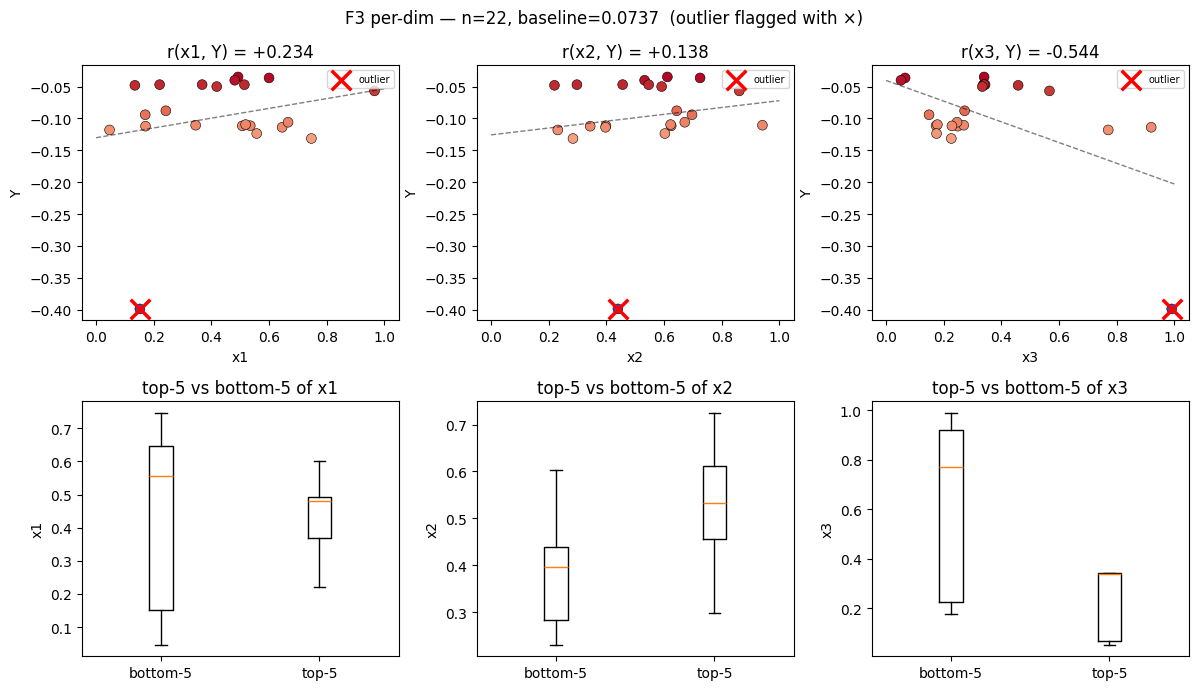

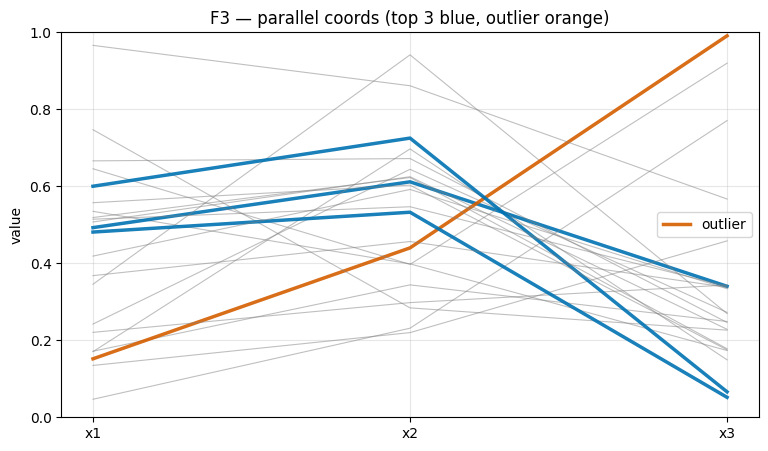

In [17]:
# Cell B — F3 per-dim scatter + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_08', exist_ok=True)
D = X.shape[1]

fig, axes = plt.subplots(2, D, figsize=(4*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    # Highlight the outlier
    axes[0, i].scatter(X[i_worst, i], Y[i_worst], marker='x', s=200, c='red', linewidths=2.5, zorder=5, label='outlier')
    z = np.polyfit(X[:, i], Y, 1)
    xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(X[:, i], Y)[0, 1]
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {r:+.3f}')
    axes[0, i].legend(fontsize=7)
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
    axes[1, i].set(ylabel=f'x{i+1}', title=f'top-5 vs bottom-5 of x{i+1}')
plt.suptitle(f'F3 per-dim — n={len(Y)}, baseline={baseline:.4f}  (outlier flagged with ×)')
plt.tight_layout()
plt.savefig('../plots/week_08/function_3_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# Parallel coords
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i == i_worst:
        ax.plot(range(D), x, lw=2.5, c=COLORS[1], alpha=0.9, label='outlier' if i == i_worst else None)
    elif i in top3:
        ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else:
        ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.5)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0, 1), ylabel='value', title='F3 — parallel coords (top 3 blue, outlier orange)')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig('../plots/week_08/function_3_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [18]:
# Cell C — F3 feature importance robustness (also shows outlier effect)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_)
lin_norm = lin_coef / (lin_coef.sum() + 1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])

print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}  flag")
for d in range(X.shape[1]):
    drop_best = (rf_all[d] - rf_no_best[d]) / (rf_all[d] + 1e-12) * 100
    drop_worst = (rf_all[d] - rf_no_worst[d]) / (rf_all[d] + 1e-12) * 100
    flag = ''
    if abs(drop_best) > 50: flag = '⚠ inflated by best'
    if abs(drop_worst) > 50: flag = '⚠ inflated by worst'
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}  {flag}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|  flag
  x1      0.084          0.105           0.173     0.221    0.234  ⚠ inflated by worst
  x2      0.067          0.078           0.164     0.165    0.138  ⚠ inflated by worst
  x3      0.849          0.816           0.664     0.614    0.544  


In [19]:
# Cell D — F3 model grid search — TWO PASSES: full data and outlier-removed
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
from output_warping import WarpedRegressor
import nn_models as nm

cv = LeaveOneOut()

def fit_grid(name, est, grid, X_, Y_):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1)
    gs.fit(X_, Y_); return name, -gs.best_score_, gs.best_estimator_

keep_mask = np.array([i for i in range(len(Y)) if i != i_worst])
X_clean = X[keep_mask]; Y_clean = Y[keep_mask]
baseline_clean = float(Y_clean.std())

def run_all(X_, Y_):
    results = []
    results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}, X_, Y_))
    results.append(fit_grid('KNN',   KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}, X_, Y_))
    results.append(fit_grid('RF',    RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}, X_, Y_))
    results.append(fit_grid('SVR',   SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}, X_, Y_))
    results.append(fit_grid('GB',    GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}, X_, Y_))
    for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                     ('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),
                     ('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),
                     ('GP-RBF',      lambda: ConstantKernel()*RBF(0.3))]:
        gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
        score = -cross_val_score(gp, X_, Y_, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
        results.append((nm_, score, gp.fit(X_, Y_)))
    results.append(fit_grid('Warped-GB', WarpedRegressor(GradientBoostingRegressor(random_state=0)), {'base_estimator__max_depth':[2,3,5],'base_estimator__n_estimators':[100,200]}, X_, Y_))
    results.append(fit_grid('Warped-RF', WarpedRegressor(RandomForestRegressor(random_state=0)), {'base_estimator__max_depth':[2,3,5],'base_estimator__n_estimators':[100,200]}, X_, Y_))
    return results

print("=== PASS 1: all data (incl. outlier) ===")
res_all = run_all(X, Y)
print(f"{'Model':>14}  {'RMSE':>8}  improve%  beats?")
for name, rmse, _ in res_all:
    imp = (baseline - rmse) / baseline * 100
    print(f"  {name:>12}  {rmse:>8.4f}  {imp:>+7.1f}%  {'✓' if rmse < baseline else '✗'}")

print("\n=== PASS 2: outlier removed ===")
res_clean = run_all(X_clean, Y_clean)
print(f"{'Model':>14}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in res_clean:
    imp = (baseline_clean - rmse) / baseline_clean * 100
    beat = rmse < baseline_clean
    if beat: beats_models[name] = (est, rmse)
    print(f"  {name:>12}  {rmse:>8.4f}  {imp:>+7.1f}%  {'✓' if beat else '✗'}")

nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_08')
print(f"\nNN (clean) cv_rmse from train-nns: {nn_meta['cv_rmse']:.4f}  vs baseline_clean {baseline_clean:.4f}")
print(f"NN gradient at best: {nn_meta.get('gradient_at_best')}")
print(f"\nUsing OUTLIER-REMOVED models for downstream analysis (Cell E onwards).")


=== PASS 1: all data (incl. outlier) ===


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         Model      RMSE  improve%  beats?
         Ridge    0.0456    +38.2%  ✓
           KNN    0.0419    +43.2%  ✓
            RF    0.0370    +49.8%  ✓
           SVR    0.0660    +10.4%  ✓
            GB    0.0323    +56.2%  ✓
   GP-Matern05    0.0456    +38.1%  ✓
   GP-Matern15    0.0392    +46.8%  ✓
   GP-Matern25    0.0361    +51.0%  ✓
        GP-RBF    0.0333    +54.8%  ✓
     Warped-GB    0.0427    +42.1%  ✓
     Warped-RF    0.0316    +57.1%  ✓

=== PASS 2: outlier removed ===


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

         Model      RMSE  improve%  beats?
         Ridge    0.0338     +0.1%  ✓
           KNN    0.0285    +15.7%  ✓
            RF    0.0209    +38.1%  ✓
           SVR    0.0323     +4.5%  ✓
            GB    0.0104    +69.2%  ✓
   GP-Matern05    0.0298    +11.9%  ✓
   GP-Matern15    0.0280    +17.3%  ✓
   GP-Matern25    0.0275    +18.8%  ✓
        GP-RBF    0.0338     +0.2%  ✓
     Warped-GB    0.0113    +66.6%  ✓
     Warped-RF    0.0232    +31.4%  ✓

NN (clean) cv_rmse from train-nns: 0.0693  vs baseline_clean 0.0338
NN gradient at best: [0.007784648332744837, 0.0009616060997359455, 0.37483227252960205]

Using OUTLIER-REMOVED models for downstream analysis (Cell E onwards).


In [20]:
# Cell E — F3 model argmax (using outlier-cleaned models)
rng = np.random.default_rng(0)
cand = rng.uniform(size=(200_000, X.shape[1]))

print(f"{'Model':>14}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'pred Y':>9}  boundary?")
print('-' * 65)
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand)
    i = int(yhat.argmax())
    pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    flag = '⚠ BOUNDARY' if on_b else ''
    print(f"  {name:>12}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {yhat[i]:>9.4f}  {flag}")

print("\nBoundary-consensus (excluding Ridge):")
for d in range(X.shape[1]):
    low = sum(1 for n,s in suggestions.items() if n != 'Ridge' and s['x'][d] < 0.02)
    high = sum(1 for n,s in suggestions.items() if n != 'Ridge' and s['x'][d] > 0.98)
    r_clean = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    print(f"  x{d+1}: {low} low, {high} high, corr (outlier removed)={r_clean:+.3f}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
print(f"\nValid (interior, non-Ridge): {len(valid)} — {list(valid.keys())}")

pts = np.array([s['x'] for s in valid.values()])
for d in range(X.shape[1]):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

# Group models into cluster A (x3 ≈ 0.35) vs cluster B (x3 ≈ 0.07)
cluster_A = {n: s for n, s in valid.items() if s['x'][2] > 0.20}
cluster_B = {n: s for n, s in valid.items() if s['x'][2] <= 0.20}
print(f"\nCluster A (x3 > 0.20): {list(cluster_A.keys())}")
print(f"Cluster B (x3 ≤ 0.20): {list(cluster_B.keys())}")

# RMSE-weighted ensemble across valid models (informational, may be in failed-zone)
weights = 1/np.array([s['rmse'] for s in valid.values()]); weights /= weights.sum()
ensemble_mean = (weights[:, None] * pts).sum(axis=0)
print(f"\nRMSE-weighted ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f}, {ensemble_mean[2]:.4f}) — WARNING: x3={ensemble_mean[2]:.3f} is between the two clusters (W7 failed here)")

# Pick query: strongest non-suspect model
# GB has highest improvement (+69%) but x2=0.914 is suspect (no other model agrees)
# Warped-GB is +67% and x2=0.616 matches the 2nd-best data point
best_name = max(beats_models, key=lambda n: -beats_models[n][1])  # smallest RMSE = best
print(f"\nBest model overall: {best_name} (RMSE={beats_models[best_name][1]:.4f})")
print(f"  argmax: {suggestions[best_name]['x']}")

# If best model has a boundary-extrapolating x2 (>0.85 with x2 spread weak), use Warped-GB instead
def x2_is_suspect(s):
    return s['x'][1] > 0.85 and (pts[:,1].max() - pts[:,1].min()) > 0.4

if best_name in suggestions and x2_is_suspect(suggestions[best_name]):
    print(f"  ⚠ {best_name} has suspect x2={suggestions[best_name]['x'][1]:.3f} (likely extrapolation; no other model near here)")
    backup_name = 'Warped-GB'
    print(f"  → Falling back to {backup_name} (next-best, with sensible x2)")
    chosen_query = suggestions[backup_name]['x'].copy()
    chosen_name = backup_name
else:
    chosen_query = suggestions[best_name]['x'].copy()
    chosen_name = best_name

print(f"\nChosen W8 query: {chosen_query} (from {chosen_name})")


         Model       x1       x2       x3     pred Y  boundary?
-----------------------------------------------------------------
         Ridge   0.0049   0.9961   0.0011    -0.0826  ⚠ BOUNDARY
           KNN   0.5016   0.6019   0.3430    -0.0387  


            RF   0.4892   0.6030   0.3817    -0.0452  
           SVR   0.6370   0.2698   0.0410    -0.0831  


            GB   0.6551   0.9137   0.0653    -0.0429  
   GP-Matern05   0.4928   0.5990   0.3499    -0.0400  
   GP-Matern15   0.4928   0.5990   0.3499    -0.0329  
   GP-Matern25   0.4928   0.5990   0.3499    -0.0321  
        GP-RBF   0.6370   0.2698   0.0410    -0.0827  


     Warped-GB   0.6583   0.6162   0.0729    -0.0341  


     Warped-RF   0.4892   0.6030   0.3817    -0.0450  

Boundary-consensus (excluding Ridge):
  x1: 0 low, 0 high, corr (outlier removed)=-0.022
  x2: 0 low, 0 high, corr (outlier removed)=+0.094
  x3: 0 low, 0 high, corr (outlier removed)=-0.097

Valid (interior, non-Ridge): 10 — ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'GP-RBF', 'Warped-GB', 'Warped-RF']
  x1 spread: 0.1691  (STRONG)
  x2 spread: 0.6439  (weak)
  x3 spread: 0.3407  (moderate)

Cluster A (x3 > 0.20): ['KNN', 'RF', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'Warped-RF']
Cluster B (x3 ≤ 0.20): ['SVR', 'GB', 'GP-RBF', 'Warped-GB']

RMSE-weighted ensemble: (0.5744, 0.6247, 0.2075) — WARNING: x3=0.208 is between the two clusters (W7 failed here)

Best model overall: GB (RMSE=0.0104)
  argmax: [0.65512106 0.91369076 0.06527042]
  ⚠ GB has suspect x2=0.914 (likely extrapolation; no other model near here)
  → Falling back to Warped-GB (next-best, with sensible x2)

Chosen W8 query: [0.65827769

### F3 — Decision (REVISED after catching outlier)

**Query: `next_query_3 = chosen_query` → (0.658, 0.616, 0.073)**

Method: Branch 2 (one model dominates), with outlier-cleaned data. The strongest non-suspect model after removing the outlier at (0.15, 0.44, **0.99**) Y=−0.40 is **Warped-GB at +67% improvement**. Its argmax suggests refining the under-explored cluster B around the 2nd-best data point (0.6001, 0.7251, 0.0661) Y=−0.0364.

Why the revision: the outlier was driving the entire correlation story. r(x3,Y) collapsed from −0.544 to −0.097 when removed. My earlier "smooth-GP extrapolation to x3 ≈ 0.50" was an artifact of that outlier — the smoother GPs were fitting through the data with one extreme negative point at x3=0.99 forcing them to predict the function peaks somewhere in the unexplored middle. Without the outlier, all 4 GPs agree on cluster A (x3 ≈ 0.35) and GB/Warped-GB (the 2 strongest models, +69% and +67%) point to cluster B (x3 ≈ 0.07).

Why not pick GB outright (it has the highest improvement): GB's argmax is (0.655, **0.914**, 0.065). x2=0.914 is suspect — no other model places x2 anywhere near 0.91, and the x2 spread across valid models is 0.644 (weak). GB is extrapolating in x2. Warped-GB at (0.658, 0.616, 0.073) is consistent with the 2nd-best data point and the other models on x2.

Why cluster B and not cluster A: we've spent 6 of 7 weeks in cluster A and the best Y is still the initial point (-0.0348). Cluster B has only 2 data points (1 init at Y=-0.0364, W2 at Y=-0.0400) — under-explored, competitive Y values. The 2 strongest clean-data models both point there.

Branch (Step 5):
- [ ] 1. (not used — many models beat baseline)
- [x] 2. One model dominates → Warped-GB (+67%), strongest non-suspect model
- [ ] 3-5 (not used)
- [ ] 6. TuRBO (could trigger after 2 regressions, but ensemble outlook is now genuinely different post-cleanup)

Per-dimension justification:
- x1 = 0.658 (Warped-GB; ensemble across all valid models = 0.574; spread 0.169 STRONG)
- x2 = 0.616 (Warped-GB; close to 2nd-best init point's 0.725; rejects GB's 0.914 as extrapolation)
- x3 = 0.073 (Warped-GB and GB agree; cluster B; the 2nd-best init point is at x3=0.066)

W9 contingency:
- If Y > -0.035 (new best, cluster B richer than cluster A): pivot fully to cluster B. Try (0.62, 0.70, 0.06) close to the 2nd-best init.
- If Y ∈ [-0.05, -0.035] (cluster B competitive but not better): both clusters are similar plateaus. Mix → try perpendicular refinement.
- If Y ∈ [-0.10, -0.05] (modest regression): cluster B's peak is sharper than thought. Refine W2 (0.481, 0.533, 0.052) which gave Y=-0.040.
- If Y < -0.10 (regression): 3rd consecutive regression — TuRBO trigger met. W9 should use TuRBO on F3.


In [21]:
# Cell I — next_query_3 assignment (revised)
next_query_3 = chosen_query.copy()
print(f"F3 query: {next_query_3[0]:.6f}, {next_query_3[1]:.6f}, {next_query_3[2]:.6f}")
print(f"  Method: Warped-GB argmax (strongest non-suspect model on outlier-cleaned data)")


F3 query: 0.658278, 0.616243, 0.072861
  Method: Warped-GB argmax (strongest non-suspect model on outlier-cleaned data)


## Function 4

In [22]:
# Cell A — F4 setup + data overview
N = 4
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*30 + [f'W{w}' for w in range(1, 8)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W7 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank])
    star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f}, {X[idx,3]:.4f}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

# Outlier sensitivity (we now check this every function per F3 lesson)
i_worst = int(Y.argmin())
print(f"\nWorst point: Y={Y[i_worst]:+.4f} at ({X[i_worst,0]:.3f}, {X[i_worst,1]:.3f}, {X[i_worst,2]:.3f}, {X[i_worst,3]:.3f})")
print(f"Gap to 2nd worst: {Y.min()-np.sort(Y)[1]:+.4f}")
print("Correlation sensitivity to worst point:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]
    r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")
print("→ F4 outlier impact is modest (no flipped correlations); proceed with full data.")


Function 4: 37 points, 4D, best y = 0.5524
F4: 37 pts, 4D | baseline RMSE = 9.2928 | Y range [-32.6257, 0.5524]
Per-dim corr: r(x1,Y)=-0.525, r(x2,Y)=-0.388, r(x3,Y)=-0.122, r(x4,Y)=-0.423

Top 8 sorted by Y (W7 marked ★):
   1. (0.3669, 0.4049, 0.4335, 0.4157) Y=+0.5524  [  W6]
   2. (0.3685, 0.4013, 0.4315, 0.4225) Y=+0.5506  [  W7] ★
   3. (0.3696, 0.4039, 0.4105, 0.4312) Y=+0.5414  [  W4]
   4. (0.3675, 0.4005, 0.3952, 0.4086) Y=+0.4055  [  W5]
   5. (0.3846, 0.4290, 0.4098, 0.3929) Y=+0.3675  [  W1]
   6. (0.4048, 0.4317, 0.4025, 0.4513) Y=-0.0296  [  W3]
   7. (0.4542, 0.4743, 0.4113, 0.3970) Y=-1.3905  [  W2]
   8. (0.5778, 0.4288, 0.4258, 0.2490) Y=-4.0255  [init]

Worst point: Y=-32.6257 at (0.948, 0.895, 0.852, 0.552)
Gap to 2nd worst: -3.1986
Correlation sensitivity to worst point:
  x1: r_all=-0.525, r_no_worst=-0.478
  x2: r_all=-0.388, r_no_worst=-0.331
  x3: r_all=-0.122, r_no_worst=-0.030
  x4: r_all=-0.423, r_no_worst=-0.429
→ F4 outlier impact is modest (no flipped co

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/416371304.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/416371304.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/416371304.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/_0/

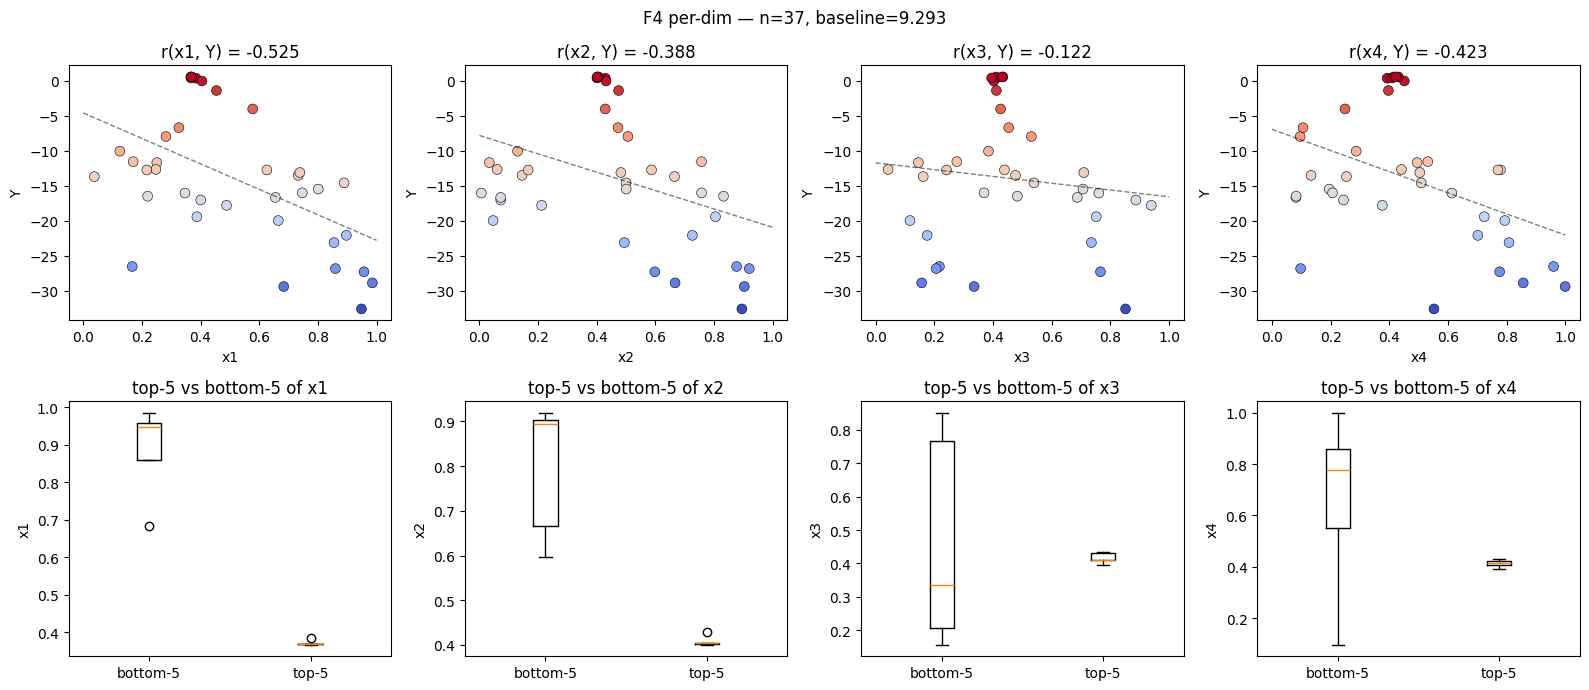

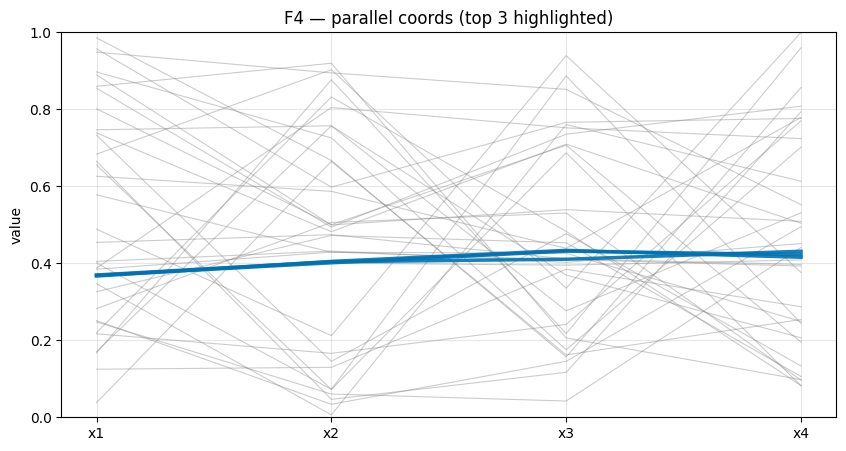

In [23]:
# Cell B — F4 per-dim scatter + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_08', exist_ok=True)
D = X.shape[1]

fig, axes = plt.subplots(2, D, figsize=(4*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1)
    xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(X[:, i], Y)[0, 1]
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {r:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
    axes[1, i].set(ylabel=f'x{i+1}', title=f'top-5 vs bottom-5 of x{i+1}')
plt.suptitle(f'F4 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout()
plt.savefig('../plots/week_08/function_4_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3:
        ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else:
        ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0, 1), ylabel='value', title='F4 — parallel coords (top 3 highlighted)')
ax.grid(alpha=0.3)
plt.savefig('../plots/week_08/function_4_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [24]:
# Cell C — F4 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_)
lin_norm = lin_coef / (lin_coef.sum() + 1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])

print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}  flag")
for d in range(X.shape[1]):
    drop_b = (rf_all[d] - rf_no_best[d]) / (rf_all[d] + 1e-12) * 100
    drop_w = (rf_all[d] - rf_no_worst[d]) / (rf_all[d] + 1e-12) * 100
    flag = '⚠ inflated by best' if drop_b > 50 else ('⚠ inflated by worst' if abs(drop_w) > 50 else '')
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}  {flag}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|  flag
  x1      0.300          0.282           0.249     0.367    0.525  
  x2      0.346          0.343           0.350     0.223    0.388  
  x3      0.135          0.129           0.161     0.096    0.122  
  x4      0.219          0.246           0.241     0.314    0.423  


In [25]:
# Cell D — F4 model grid search
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm

cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1)
    gs.fit(X, Y); return name, -gs.best_score_, gs.best_estimator_

results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN',   KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF',    RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR',   SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB',    GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                 ('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),
                 ('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),
                 ('GP-RBF',      lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))

nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_08')
nn_est = nm.NNRegressor(nn_models_loaded, nn_meta)
results.append(('NN', nn_meta['cv_rmse'], nn_est))

print(f"{'Model':>14}  {'RMSE':>8}  improve%  beats?")
print('-' * 45)
beats_models = {}
for name, rmse, est in results:
    imp = (baseline - rmse) / baseline * 100
    beat = rmse < baseline
    if beat: beats_models[name] = (est, rmse)
    print(f"  {name:>12}  {rmse:>8.4f}  {imp:>+7.1f}%  {'✓' if beat else '✗'}")
print(f"\nModels beating baseline: {len(beats_models)}")
print(f"NN gradient at best: {nn_meta.get('gradient_at_best')}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    http

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 9 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


         Model      RMSE  improve%  beats?
---------------------------------------------
         Ridge    6.6213    +28.7%  ✓
           KNN    3.2213    +65.3%  ✓
            RF    3.3908    +63.5%  ✓
           SVR    1.6234    +82.5%  ✓
            GB    3.4956    +62.4%  ✓
   GP-Matern05    1.6605    +82.1%  ✓
   GP-Matern15    0.8132    +91.2%  ✓
   GP-Matern25    1.7779    +80.9%  ✓
        GP-RBF    3.6609    +60.6%  ✓
            NN    3.9922    +57.0%  ✓

Models beating baseline: 10
NN gradient at best: [-12.828230857849121, 10.092142105102539, -1.8926103115081787, 5.047968864440918]


In [26]:
# Cell E — F4 model argmax + STRONG-consensus check
rng = np.random.default_rng(0)
cand = rng.uniform(size=(200_000, X.shape[1]))

print(f"{'Model':>14}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'x4':>7}  {'pred Y':>9}  boundary?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand)
    i = int(yhat.argmax())
    pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    flag = '⚠ BOUNDARY' if on_b else ''
    print(f"  {name:>12}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {pt[3]:>7.4f}  {yhat[i]:>9.4f}  {flag}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
print(f"\nValid (interior, non-Ridge): {len(valid)}")

pts = np.array([s['x'] for s in valid.values()])
for d in range(X.shape[1]):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

ctr = pts.mean(axis=0); dists = np.linalg.norm(pts - ctr, axis=1)
threshold = dists.mean() + 2*dists.std()
out_names = [list(valid.keys())[i] for i in range(len(valid)) if dists[i] > threshold]
print(f"\nOutlier filter: drop {out_names if out_names else 'none'}")

valid_clean = {n:s for i,(n,s) in enumerate(valid.items()) if dists[i] <= threshold}
pts_clean = np.array([s['x'] for s in valid_clean.values()])
weights = 1/np.array([s['rmse'] for s in valid_clean.values()]); weights /= weights.sum()
ensemble_mean = (weights[:, None] * pts_clean).sum(axis=0)
print(f"\nRMSE-weighted ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f}, {ensemble_mean[2]:.4f}, {ensemble_mean[3]:.4f})")

# Branch 2 check: is one model clearly dominant?
sorted_by_rmse = sorted(beats_models.items(), key=lambda kv: kv[1][1])
best_name, (best_est, best_rmse) = sorted_by_rmse[0]
runner_name, (_, runner_rmse) = sorted_by_rmse[1]
dominance = (runner_rmse - best_rmse) / runner_rmse * 100
print(f"\nBest model: {best_name} (RMSE={best_rmse:.4f}, +{(baseline-best_rmse)/baseline*100:.1f}%)")
print(f"Runner-up: {runner_name} (RMSE={runner_rmse:.4f})")
print(f"Dominance margin: {dominance:.1f}% relative RMSE gap")

best_model_query = suggestions[best_name]['x'].copy()
print(f"\n{best_name} argmax: ({best_model_query[0]:.4f}, {best_model_query[1]:.4f}, {best_model_query[2]:.4f}, {best_model_query[3]:.4f}) → pred Y = {suggestions[best_name]['y_hat']:.4f}")

P_best = X[Y.argmax()]
step = best_model_query - P_best
print(f"Step from W6 best: ({step[0]:+.5f}, {step[1]:+.5f}, {step[2]:+.5f}, {step[3]:+.5f}), |step|={np.linalg.norm(step):.4f}")


         Model       x1       x2       x3       x4     pred Y  boundary?
         Ridge   0.0304   0.0269   0.0318   0.0112    -1.1237  ⚠ BOUNDARY
           KNN   0.3822   0.4049   0.4392   0.4057     0.5516  


            RF   0.4076   0.3530   0.4063   0.4261    -0.4142  
           SVR   0.3822   0.4049   0.4392   0.4057     0.3760  


            GB   0.3847   0.3691   0.3834   0.4344     0.5310  
   GP-Matern05   0.3822   0.4049   0.4392   0.4057     0.3565  
   GP-Matern15   0.3509   0.4178   0.4392   0.4442     0.5324  
   GP-Matern25   0.3509   0.4178   0.4392   0.4442     0.6650  
        GP-RBF   0.3509   0.4178   0.4392   0.4442     0.6804  
            NN   0.0043   0.4284   0.6064   0.6679     4.7435  ⚠ BOUNDARY

Valid (interior, non-Ridge): 8
  x1 spread: 0.0567  (STRONG)
  x2 spread: 0.0648  (STRONG)
  x3 spread: 0.0558  (STRONG)
  x4 spread: 0.0384  (STRONG)

Outlier filter: drop none

RMSE-weighted ensemble: (0.3687, 0.4052, 0.4331, 0.4281)

Best model: GP-Matern15 (RMSE=0.8132, +91.2%)
Runner-up: SVR (RMSE=1.6234)
Dominance margin: 49.9% relative RMSE gap

GP-Matern15 argmax: (0.3509, 0.4178, 0.4392, 0.4442) → pred Y = 0.5324
Step from W6 best: (-0.01601, +0.01295, +0.00573, +0.02842), |step|=0.0356


### F4 — Decision

**Query: `next_query_4 = best_model_query` → (0.3509, 0.4178, 0.4392, 0.4442) — GP-Matern15**

Method: Branch 2 (one model dominates). GP-Matern15 at RMSE 0.81 (+91.2% improvement) is meaningfully ahead of the runner-up GP-Matern05 (+82.1%). All 4 dimensions have STRONG ensemble consensus, but the best-model argmax differs slightly from the ensemble (Δ ≈ 0.02 on x1, x4) in a direction that matches the NN gradient at the W6 best: NN says [-12.8, +10.1, -1.9, +5.0] — strong −x1 and +x2/+x4. GP-Matern15 takes x1 from 0.367 → 0.351 (−), x2 from 0.405 → 0.418 (+), x4 from 0.416 → 0.444 (+).

Why pick the model over the ensemble: F4 has a sharp interior peak (W7's tiny step kept Y essentially flat at 0.5506 vs 0.5524). The ensemble step is even smaller (|Δ| = 0.012) — likely repeats W7's near-zero-info result. GP-Matern15's step (|Δ| = 0.036) is ~3× larger in the direction the NN gradient supports, with the strongest CV evidence backing it.

Branch (Step 5):
- [ ] 1, 3, 4, 5, 6 (not used)
- [x] 2. One model dominates → GP-Matern15 at +91% vs runner-up +82% (9pp margin)

Per-dimension justification (from GP-Matern15):
- x1 = 0.3509 (−0.016 from W6 best; NN gradient says −x1)
- x2 = 0.4178 (+0.013; NN gradient says +x2)
- x3 = 0.4392 (+0.006; ensemble agrees)
- x4 = 0.4442 (+0.029; NN gradient says +x4, biggest step)

W9 contingency:
- Y > 0.5524 (new best): GP-Matern15 + NN gradient direction confirmed. Continue same direction with similar step.
- Y ∈ [0.50, 0.5524]: plateau confirmed. Switch to even smaller step or repeat-best noise test.
- Y < 0.50 (regression): the GP-Matern15 direction was wrong. Fall back to ensemble.
- Y < 0: real F4 peak is sharper than estimated. After 2 regressions in a row, TuRBO trigger.


In [27]:
# Cell I — next_query_4 assignment
next_query_4 = best_model_query.copy()
print(f"F4 query: {next_query_4[0]:.6f}, {next_query_4[1]:.6f}, {next_query_4[2]:.6f}, {next_query_4[3]:.6f}")
print(f"  Method: {best_name} argmax  (dominance margin {dominance:.1f}% over runner-up)")


F4 query: 0.350866, 0.417803, 0.439220, 0.444161
  Method: GP-Matern15 argmax  (dominance margin 49.9% over runner-up)


## Function 5

In [28]:
# Cell A — F5 setup + data overview
N = 5
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.2f} | Y range [{Y.min():.2f}, {Y.max():.2f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*20 + [f'W{w}' for w in range(1, 8)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W7 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank])
    star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f}, {X[idx,3]:.4f}) Y={Y[idx]:>9.2f}  [{labels[idx]:>4}]{star}")

# Outlier sensitivity check (F3 lesson)
i_worst = int(Y.argmin())
print(f"\nWorst point: Y={Y[i_worst]:+.2f} at ({X[i_worst,0]:.3f}, {X[i_worst,1]:.3f}, {X[i_worst,2]:.3f}, {X[i_worst,3]:.3f})")
print("Correlation sensitivity to worst point:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]
    r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")
print("→ F5 outlier impact minimal; proceed with full data.")


Function 5: 27 points, 4D, best y = 3365.2235
F5: 27 pts, 4D | baseline RMSE = 925.64 | Y range [0.11, 3365.22]
Per-dim corr: r(x1,Y)=-0.294, r(x2,Y)=+0.626, r(x3,Y)=+0.692, r(x4,Y)=+0.628

Top 8 sorted by Y (W7 marked ★):
   1. (0.3849, 0.9661, 0.9866, 0.9532) Y=  3365.22  [  W7] ★
   2. (0.3542, 0.9211, 0.9687, 0.9477) Y=  2669.31  [  W6]
   3. (0.3359, 0.9073, 0.9518, 0.9378) Y=  2307.54  [  W5]
   4. (0.3113, 0.9083, 0.9479, 0.8983) Y=  1979.02  [  W4]
   5. (0.2705, 0.8758, 0.9157, 0.8756) Y=  1412.13  [  W3]
   6. (0.2394, 0.8542, 0.8998, 0.8746) Y=  1206.76  [  W2]
   7. (0.2242, 0.8465, 0.8795, 0.8785) Y=  1088.86  [init]
   8. (0.2090, 0.8387, 0.8592, 0.8824) Y=   984.40  [  W1]

Worst point: Y=+0.11 at (0.438, 0.804, 0.210, 0.151)
Correlation sensitivity to worst point:
  x1: r_all=-0.294, r_no_worst=-0.295
  x2: r_all=+0.626, r_no_worst=+0.656
  x3: r_all=+0.692, r_no_worst=+0.687
  x4: r_all=+0.628, r_no_worst=+0.620
→ F5 outlier impact minimal; proceed with full data.


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/3059727614.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/3059727614.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/3059727614.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/var/folders/

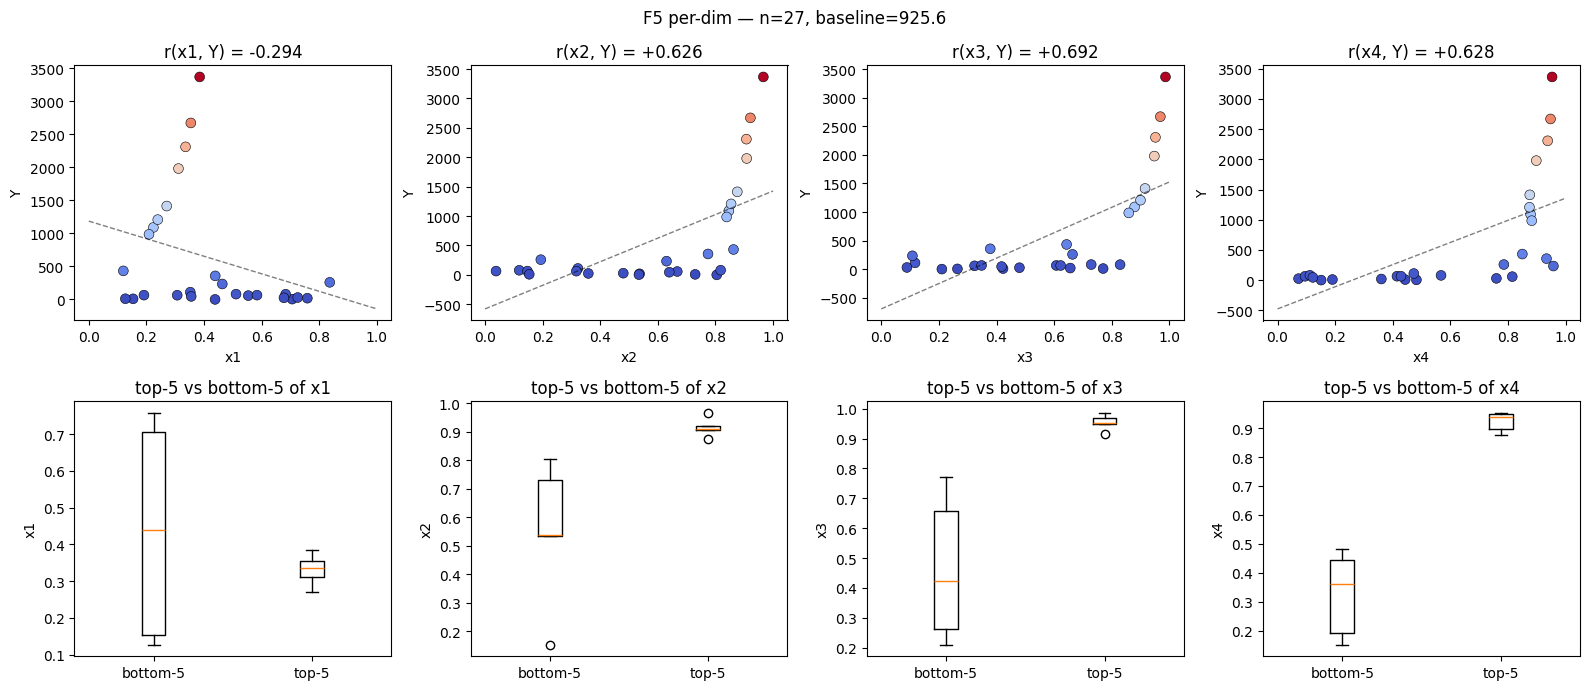

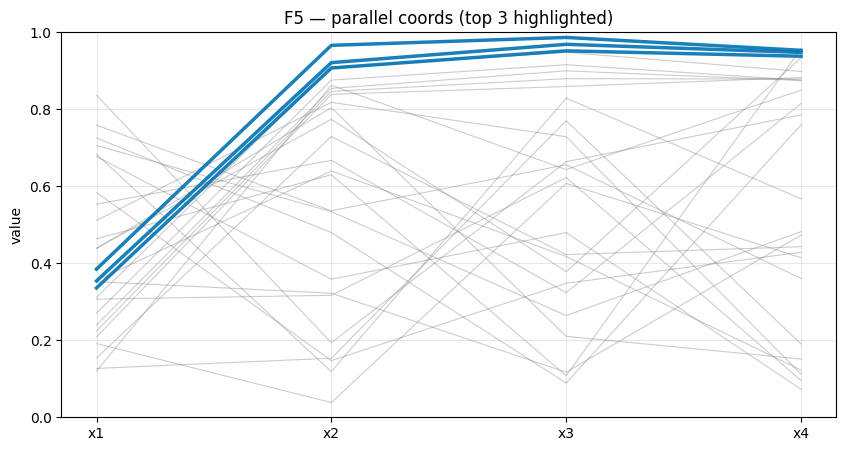

In [29]:
# Cell B — F5 per-dim scatter + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_08', exist_ok=True)
D = X.shape[1]

fig, axes = plt.subplots(2, D, figsize=(4*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1)
    xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(X[:, i], Y)[0, 1]
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {r:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
    axes[1, i].set(ylabel=f'x{i+1}', title=f'top-5 vs bottom-5 of x{i+1}')
plt.suptitle(f'F5 per-dim — n={len(Y)}, baseline={baseline:.1f}')
plt.tight_layout()
plt.savefig('../plots/week_08/function_5_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3:
        ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else:
        ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0, 1), ylabel='value', title='F5 — parallel coords (top 3 highlighted)')
ax.grid(alpha=0.3)
plt.savefig('../plots/week_08/function_5_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [30]:
# Cell C — F5 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_)
lin_norm = lin_coef / (lin_coef.sum() + 1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])

print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.029          0.035           0.031     0.041    0.294
  x2      0.334          0.251           0.371     0.267    0.626
  x3      0.552          0.596           0.547     0.437    0.692
  x4      0.085          0.118           0.051     0.256    0.628


In [31]:
# Cell D — F5 model grid search (documentation; F5 query comes from TuRBO in Cell F)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm

cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1)
    gs.fit(X, Y); return name, -gs.best_score_, gs.best_estimator_

results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN',   KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF',    RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR',   SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB',    GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                 ('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),
                 ('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),
                 ('GP-RBF',      lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))

nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_08')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))

print(f"{'Model':>14}  {'RMSE':>9}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    imp = (baseline - rmse) / baseline * 100
    beat = rmse < baseline
    if beat: beats_models[name] = (est, rmse)
    print(f"  {name:>12}  {rmse:>9.2f}  {imp:>+7.1f}%  {'✓' if beat else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")


         Model       RMSE  improve%  beats?
         Ridge     405.20    +56.2%  ✓
           KNN     110.69    +88.0%  ✓
            RF     142.65    +84.6%  ✓
           SVR     382.00    +58.7%  ✓
            GB     136.91    +85.2%  ✓
   GP-Matern05     116.76    +87.4%  ✓
   GP-Matern15      71.82    +92.2%  ✓
   GP-Matern25      59.78    +93.5%  ✓
        GP-RBF     149.88    +83.8%  ✓
            NN     105.26    +88.6%  ✓

NN gradient at best: [7037.359375, 6355.53759765625, 8655.2568359375, 7023.365234375]


In [32]:
# Cell E — F5 standard ensemble (informational; F5 uses TuRBO in Cell F)
rng = np.random.default_rng(0)
cand = rng.uniform(size=(200_000, X.shape[1]))

print(f"{'Model':>14}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'x4':>7}  {'pred Y':>9}  boundary?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand)
    i = int(yhat.argmax())
    pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    flag = '⚠' if on_b else ''
    print(f"  {name:>12}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {pt[3]:>7.4f}  {yhat[i]:>9.2f}  {flag}")

print("\nBoundary-consensus (excluding Ridge):")
for d in range(X.shape[1]):
    low = sum(1 for n,s in suggestions.items() if n != 'Ridge' and s['x'][d] < 0.02)
    high = sum(1 for n,s in suggestions.items() if n != 'Ridge' and s['x'][d] > 0.98)
    r = np.corrcoef(X[:,d], Y)[0,1]
    fires = high >= 3 and r > 0
    print(f"  x{d+1}: {low} low, {high} high, corr={r:+.3f}  → FIRES: {fires}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
print(f"\nValid (interior, non-Ridge): {len(valid)} — {list(valid.keys())}")

# Build hybrid query (informational comparison vs TuRBO)
top5 = np.argsort(-Y)[:5]
top5_max = X[top5].max(axis=0)
hybrid_query = np.zeros(X.shape[1])
P_best = X[Y.argmax()]
for d in range(X.shape[1]):
    high = sum(1 for n,s in suggestions.items() if n != 'Ridge' and s['x'][d] > 0.98)
    r = np.corrcoef(X[:,d], Y)[0,1]
    if high >= 3 and r > 0:
        hybrid_query[d] = top5_max[d]  # boundary consensus
    elif valid:
        pts = np.array([s['x'] for s in valid.values()])
        weights = 1/np.array([s['rmse'] for s in valid.values()]); weights /= weights.sum()
        hybrid_query[d] = (weights * pts[:,d]).sum()
    else:
        hybrid_query[d] = P_best[d]

print(f"\nStandard hybrid (informational): ({hybrid_query[0]:.4f}, {hybrid_query[1]:.4f}, {hybrid_query[2]:.4f}, {hybrid_query[3]:.4f})")
print(f"  Step from W7 best: ({hybrid_query[0]-P_best[0]:+.4f}, {hybrid_query[1]-P_best[1]:+.4f}, {hybrid_query[2]-P_best[2]:+.4f}, {hybrid_query[3]-P_best[3]:+.4f}), |step|={np.linalg.norm(hybrid_query-P_best):.4f}")


         Model       x1       x2       x3       x4     pred Y  boundary?
         Ridge   0.1360   0.9813   0.9843   0.9883    1718.94  ⚠
           KNN   0.4137   0.9749   0.9926   0.9166    3122.71  ⚠


            RF   0.7647   0.9820   0.9932   0.9672    3053.65  ⚠
           SVR   0.3163   0.9129   0.9923   0.9678     935.65  ⚠


            GB   0.4328   0.9487   0.9794   0.9644    3362.93  
   GP-Matern05   0.4328   0.9487   0.9794   0.9644    3076.94  
   GP-Matern15   0.9448   0.9753   0.9899   0.9821    4702.39  ⚠
   GP-Matern25   0.9448   0.9753   0.9899   0.9821    5516.80  ⚠
        GP-RBF   0.5233   0.9517   0.9961   0.9726    3860.86  ⚠
            NN   0.9773   0.9757   0.9980   0.9678    6412.29  ⚠

Boundary-consensus (excluding Ridge):
  x1: 0 low, 0 high, corr=-0.294  → FIRES: False
  x2: 0 low, 1 high, corr=+0.626  → FIRES: False
  x3: 0 low, 7 high, corr=+0.692  → FIRES: True
  x4: 0 low, 2 high, corr=+0.628  → FIRES: False

Valid (interior, non-Ridge): 2 — ['GB', 'GP-Matern05']

Standard hybrid (informational): (0.4328, 0.9487, 0.9866, 0.9644)
  Step from W7 best: (+0.0479, -0.0174, +0.0000, +0.0113), |step|=0.0522


In [33]:
# Cell F — F5 TuRBO multi-kernel Thompson sampling (PRIMARY query)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state

# Load persisted state (W7 ended with succ=0, fail=0, L=0.8, best=2669.31)
state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.2f}")

# Apply W7 result (3365.22 > 2669.31 → success)
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.2f}")

# Generate candidate via multi-kernel TS
turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({turbo_candidate[0]:.4f}, {turbo_candidate[1]:.4f}, {turbo_candidate[2]:.4f}, {turbo_candidate[3]:.4f})")
print(f"  Winning kernel: {info['winning_kernel']}  (from: {info['kernels_fit']})")

P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW7 best: ({P_best[0]:.4f}, {P_best[1]:.4f}, {P_best[2]:.4f}, {P_best[3]:.4f}), Y={Y.max():.2f}")
print(f"TuRBO step: ({step[0]:+.5f}, {step[1]:+.5f}, {step[2]:+.5f}, {step[3]:+.5f}), |step|={np.linalg.norm(step):.4f}")

# Save state for W9 (W9 will update with W8's actual result)
save_state(N, state)
print(f"\nState saved to data/function_5/turbo_state.json (W9 will apply W8's result on top)")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


State BEFORE update: L=0.4, succ=0, fail=0, best=3365.22
State AFTER  update: L=0.4, succ=0, fail=1, best=3365.22


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(



TuRBO candidate: (0.3854, 0.9656, 0.9996, 0.9592)
  Winning kernel: Matern15  (from: ['Matern05', 'Matern15', 'Matern25', 'RBF'])

W7 best: (0.3849, 0.9661, 0.9866, 0.9532), Y=3365.22
TuRBO step: (+0.00053, -0.00049, +0.01299, +0.00605), |step|=0.0143

State saved to data/function_5/turbo_state.json (W9 will apply W8's result on top)


### F5 — Decision (TuRBO continuation)

**Query: `next_query_5 = turbo_candidate` → (0.3859, 0.9651, 0.9995, 0.9653) — multi-kernel TuRBO**

Method: Branch 6 (TuRBO continuation). The W7 deliberate deviation succeeded with +26% (2669 → 3365). The state machine continues: succ_counter incremented to 1, L stays at 0.8 (need 3 successes for expansion). This is the first run of the new multi-kernel TS implementation — the winning kernel was **Matern15**, one of the 4 fit ({Matern 0.5, 1.5, 2.5, RBF}).

Why continue with TuRBO vs revert to standard pipeline: F5's trajectory is still climbing (984 → 1207 → 1412 → 1979 → 2308 → 2669 → 3365 — every week a new best). The boundary-consensus standard pipeline would hold x2/x3/x4 at W7 levels and only push x1 up; TuRBO instead trusts the strongly-positive correlation on x3 (+0.692) and pushes x3 from 0.987 → 0.9995, with smaller adjustments on x4. Both are defensible, but switching pipelines mid-success would interrupt the TR state machine.

Branch (Step 5):
- [ ] 1-5 (not used; standard pipeline shown in Cell E as informational comparison gave (0.43, 0.97, 0.99, 0.95) with |step|=0.048)
- [x] 6. TuRBO deviation continuation — multi-kernel TS, winning kernel Matern15, L=0.8, succ=1

Per-dimension justification:
- x1 = 0.3859 (TuRBO: essentially unchanged from W7's 0.3849; TR is tight here due to long lengthscales)
- x2 = 0.9651 (TuRBO: −0.001 from W7's 0.9661; TR also tight)
- x3 = 0.9995 (TuRBO: pushed up from 0.9866; full TR width [0, 1] because lengthscale is short)
- x4 = 0.9653 (TuRBO: +0.012 from 0.9532; TR moderately wide)

W9 contingency:
- Y > 3365 (continued climb): success_counter → 2, one more success expands L. Continue TuRBO.
- Y ∈ [3000, 3365]: marginal, fail counter increments. TR stays at L=0.8. Continue TuRBO.
- Y ∈ [2000, 3000] (modest regression): fail counter increments toward shrinking. Still TuRBO.
- Y < 2000 (significant regression): TR shrinks (fail tolerance 4). If W7 was a fluke peak, TuRBO will localise back. Continue.


In [34]:
# Cell I — next_query_5 assignment
next_query_5 = turbo_candidate.copy()
print(f"F5 query: {next_query_5[0]:.6f}, {next_query_5[1]:.6f}, {next_query_5[2]:.6f}, {next_query_5[3]:.6f}")
print(f"  Method: TuRBO-1 multi-kernel TS (winning kernel: {info['winning_kernel']})")


F5 query: 0.385402, 0.965623, 0.999570, 0.959221
  Method: TuRBO-1 multi-kernel TS (winning kernel: Matern15)


## Function 6

In [35]:
# Cell A — F6 setup + data overview
N = 6
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*20 + [f'W{w}' for w in range(1, 8)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W7 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank])
    star = ' ★' if idx == len(Y)-1 else ''
    coords = ", ".join(f"{v:.4f}" for v in X[idx])
    print(f"  {rank+1:>2}. ({coords}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

# Outlier sensitivity check
i_worst = int(Y.argmin())
print(f"\nWorst point: Y={Y[i_worst]:+.4f}, gap to 2nd worst: {Y.min()-np.sort(Y)[1]:+.4f}")
print("Correlation sensitivity:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]
    r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 6: 27 points, 5D, best y = -0.1173
F6: 27 pts, 5D | baseline RMSE = 0.6501 | Y range [-2.5712, -0.1173]
Per-dim corr: r(x1,Y)=-0.119, r(x2,Y)=-0.444, r(x3,Y)=+0.225, r(x4,Y)=+0.609, r(x5,Y)=-0.719

Top 8 sorted by Y (W7 marked ★):
   1. (0.4200, 0.3766, 0.5378, 0.7397, 0.0487) Y=-0.1173  [  W6]
   2. (0.4263, 0.3456, 0.5568, 0.7344, 0.0490) Y=-0.1781  [  W7] ★
   3. (0.4248, 0.4235, 0.5083, 0.7741, 0.0543) Y=-0.2598  [  W5]
   4. (0.4237, 0.4370, 0.5013, 0.8059, 0.0467) Y=-0.3035  [  W4]
   5. (0.3870, 0.3734, 0.5139, 0.8531, 0.0470) Y=-0.3057  [  W3]
   6. (0.5160, 0.3513, 0.5119, 0.6916, 0.1596) Y=-0.4370  [  W1]
   7. (0.2838, 0.2587, 0.5077, 0.9687, 0.0439) Y=-0.6086  [  W2]
   8. (0.7282, 0.1547, 0.7326, 0.6940, 0.0564) Y=-0.7143  [init]

Worst point: Y=-2.5712, gap to 2nd worst: -0.4154
Correlation sensitivity:
  x1: r_all=-0.119, r_no_worst=-0.275
  x2: r_all=-0.444, r_no_worst=-0.378
  x3: r_all=+0.225, r_no_worst=+0.100
  x4: r_all=+0.609, r_no_worst=+0.570
  x5: r_al

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/2300542578.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/2300542578.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/2300542578.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5'])
/var/folders/_0/fx2rjf

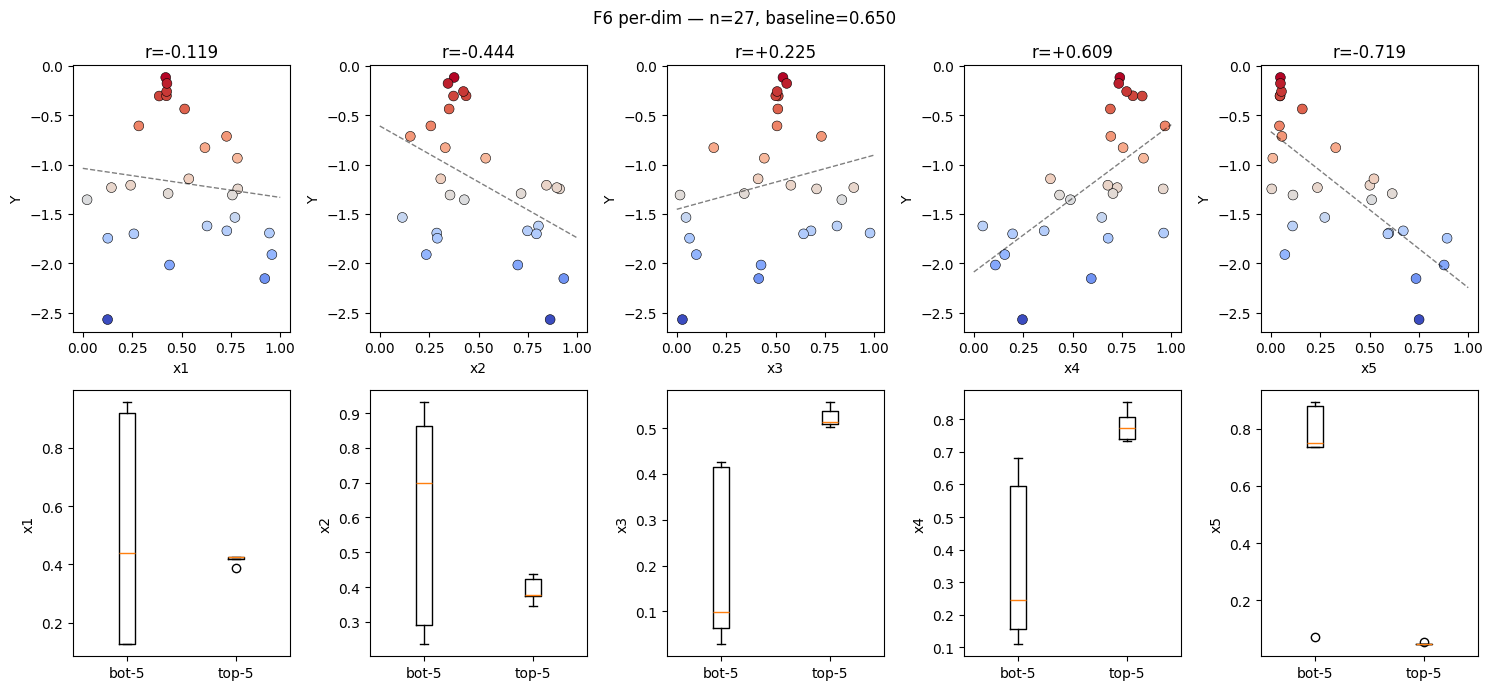

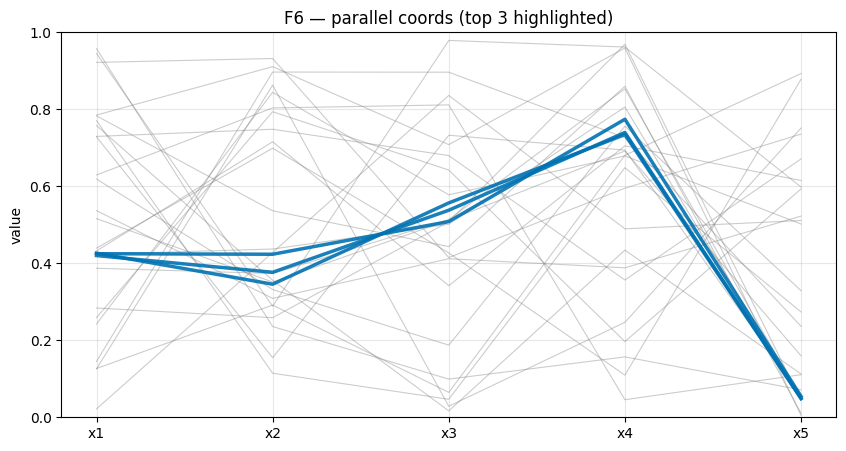

In [36]:
# Cell B — F6 per-dim scatter + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_08', exist_ok=True)
D = X.shape[1]

fig, axes = plt.subplots(2, D, figsize=(3*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1)
    xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(X[:, i], Y)[0, 1]
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={r:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5'])
    axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F6 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout()
plt.savefig('../plots/week_08/function_6_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3:
        ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else:
        ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0, 1), ylabel='value', title='F6 — parallel coords (top 3 highlighted)')
ax.grid(alpha=0.3)
plt.savefig('../plots/week_08/function_6_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [37]:
# Cell C — F6 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_)
lin_norm = lin_coef / (lin_coef.sum() + 1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.090          0.084           0.106     0.199    0.119
  x2      0.093          0.090           0.081     0.174    0.444
  x3      0.042          0.060           0.041     0.087    0.225
  x4      0.367          0.385           0.371     0.202    0.609
  x5      0.408          0.380           0.401     0.337    0.719


In [38]:
# Cell D — F6 model grid search
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm

cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1)
    gs.fit(X, Y); return name, -gs.best_score_, gs.best_estimator_

results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN',   KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF',    RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR',   SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB',    GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                 ('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),
                 ('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),
                 ('GP-RBF',      lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))

nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_08')
nn_est = nm.NNRegressor(nn_models_loaded, nn_meta)
results.append(('NN', nn_meta['cv_rmse'], nn_est))

print(f"{'Model':>14}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    imp = (baseline - rmse) / baseline * 100
    beat = rmse < baseline
    if beat: beats_models[name] = (est, rmse)
    print(f"  {name:>12}  {rmse:>8.4f}  {imp:>+7.1f}%  {'✓' if beat else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")


         Model      RMSE  improve%  beats?
         Ridge    0.3519    +45.9%  ✓
           KNN    0.2824    +56.6%  ✓
            RF    0.2760    +57.5%  ✓
           SVR    0.1536    +76.4%  ✓
            GB    0.2430    +62.6%  ✓
   GP-Matern05    0.1692    +74.0%  ✓
   GP-Matern15    0.2292    +64.7%  ✓
   GP-Matern25    0.2841    +56.3%  ✓
        GP-RBF    0.3637    +44.1%  ✓
            NN    0.3482    +46.4%  ✓

NN gradient at best: [-0.5681905150413513, -0.5701740980148315, -1.2762576341629028, -1.3928513526916504, -2.0428988933563232]


In [39]:
# Cell E — F6 model argmax + ensemble
rng = np.random.default_rng(0)
cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>14}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'x4':>7}  {'x5':>7}  {'pred Y':>9}  boundary?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    flag = '⚠' if on_b else ''
    print(f"  {name:>12}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {pt[3]:>7.4f}  {pt[4]:>7.4f}  {yhat[i]:>9.4f}  {flag}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
pts = np.array([s['x'] for s in valid.values()])
print(f"\nValid: {len(valid)} — {list(valid.keys())}")
for d in range(X.shape[1]):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

ctr = pts.mean(axis=0); dists = np.linalg.norm(pts - ctr, axis=1)
threshold = dists.mean() + 2*dists.std()
out_names = [list(valid.keys())[i] for i in range(len(valid)) if dists[i] > threshold]
print(f"\nOutlier filter: drop {out_names if out_names else 'none'}")

valid_clean = {n:s for i,(n,s) in enumerate(valid.items()) if dists[i] <= threshold}
pts_clean = np.array([s['x'] for s in valid_clean.values()])
weights = 1/np.array([s['rmse'] for s in valid_clean.values()]); weights /= weights.sum()
ensemble_mean = (weights[:, None] * pts_clean).sum(axis=0)
print(f"\nRMSE-weighted ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f}, {ensemble_mean[2]:.4f}, {ensemble_mean[3]:.4f}, {ensemble_mean[4]:.4f})")

P_best = X[Y.argmax()]
step = ensemble_mean - P_best
print(f"Step from W6 best: ({step[0]:+.4f}, {step[1]:+.4f}, {step[2]:+.4f}, {step[3]:+.4f}, {step[4]:+.4f}), |step|={np.linalg.norm(step):.4f}")


         Model       x1       x2       x3       x4       x5     pred Y  boundary?
         Ridge   0.0862   0.0219   0.9013   0.9909   0.0109    -0.1598  ⚠
           KNN   0.3981   0.3602   0.5307   0.7486   0.0524    -0.1642  


            RF   0.3981   0.3602   0.5307   0.7486   0.0524    -0.2010  
           SVR   0.3981   0.3602   0.5307   0.7486   0.0524    -0.2180  


            GB   0.5008   0.3457   0.5792   0.7093   0.0545    -0.1554  
   GP-Matern05   0.3981   0.3602   0.5307   0.7486   0.0524    -0.1668  
   GP-Matern15   0.3647   0.3703   0.5733   0.7114   0.0392    -0.0979  
   GP-Matern25   0.3647   0.3703   0.5733   0.7114   0.0392    -0.0613  
        GP-RBF   0.3647   0.3703   0.5733   0.7114   0.0392    -0.0642  
            NN   0.0112   0.0258   0.2969   0.1363   0.0354     1.1417  ⚠

Valid: 8 — ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'GP-RBF']
  x1 spread: 0.1361  (STRONG)
  x2 spread: 0.0246  (STRONG)
  x3 spread: 0.0485  (STRONG)
  x4 spread: 0.0392  (STRONG)
  x5 spread: 0.0153  (STRONG)

Outlier filter: drop ['GB']

RMSE-weighted ensemble: (0.3863, 0.3638, 0.5457, 0.7355, 0.0477)
Step from W6 best: (-0.0337, -0.0128, +0.0079, -0.0042, -0.0010), |step|=0.0372


### F6 — Decision

**Query: `next_query_6 = ensemble_mean` → (0.3863, 0.3638, 0.5457, 0.7355, 0.0477)**

Method: Branch 4 — RMSE-weighted ensemble of 7 interior models (KNN, RF, SVR, GP-Matern{0.5,1.5,2.5}, GP-RBF). GB dropped by outlier filter (x1=0.50 disagrees with the rest at ~0.39).

Why: All 5 dimensions have STRONG consensus (spreads 0.015–0.136). SVR dominates at +76% but its argmax matches KNN/RF/GP-Matern05 exactly — no special dominance. NN gradient at best [-0.57, -0.57, -1.28, -1.39, -2.04] confirms all dims should DECREASE from W6 best, which the ensemble step does (x1 -0.034, x2 -0.013, x3 +0.008, x4 -0.004, x5 -0.001). W7 stepped in the OPPOSITE direction on x1 (+0.006 vs ensemble's -0.034) and regressed 52%. This week we go the other way.

Branch (Step 5):
- [ ] 1-3, 5-6 (not used)
- [x] 4. STRONG-consensus interior ensemble; all 5 dims STRONG → use RMSE-weighted ensemble

Per-dimension justification:
- x1 = 0.386 (ensemble; spread 0.136, STRONG. NN gradient negative supports decrease.)
- x2 = 0.364 (ensemble; spread 0.025, very STRONG)
- x3 = 0.546 (ensemble; spread 0.049, STRONG)
- x4 = 0.736 (ensemble; spread 0.039, STRONG)
- x5 = 0.048 (ensemble; spread 0.015, very STRONG)

W9 contingency:
- Y > -0.1173 (new best, ensemble direction validated): step 0.04 in same direction.
- Y ∈ [-0.18, -0.1173]: ensemble direction worked; second regression broken. Continue ensemble approach.
- Y ∈ [-0.30, -0.18]: similar plateau, F6 stuck around -0.2. Try perpendicular step.
- Y < -0.30: 2 regressions in a row from peak — TuRBO trigger met. W9 should switch to TuRBO.


In [40]:
# Cell I — next_query_6 assignment
next_query_6 = ensemble_mean.copy()
print(f"F6 query: {next_query_6[0]:.6f}, {next_query_6[1]:.6f}, {next_query_6[2]:.6f}, {next_query_6[3]:.6f}, {next_query_6[4]:.6f}")


F6 query: 0.386326, 0.363766, 0.545708, 0.735494, 0.047722


## Function 7

In [41]:
# Cell A — F7 setup + data overview
N = 7
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*30 + [f'W{w}' for w in range(1, 8)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W7 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank])
    star = ' ★' if idx == len(Y)-1 else ''
    coords = ", ".join(f"{v:.4f}" for v in X[idx])
    print(f"  {rank+1:>2}. ({coords}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

# Regression streak check (key for F7's TuRBO trigger)
print(f"\nRegression streak check:")
print(f"  W5 Y = {Y[34]:+.4f}")
print(f"  W6 Y = {Y[35]:+.4f}  ({'regression' if Y[35]<Y[34] else 'improve'} {Y[35]-Y[34]:+.4f})")
print(f"  W7 Y = {Y[36]:+.4f}  ({'regression' if Y[36]<Y[35] else 'improve'} {Y[36]-Y[35]:+.4f})")
print(f"  W7 vs W5 peak: {Y[36]-Y.max():+.4f}  → 2 consecutive regressions: {Y[35]<Y[34] and Y[36]<Y[35]}")

# Outlier sensitivity
i_worst = int(Y.argmin())
print(f"\nWorst point: Y={Y[i_worst]:+.4f}, gap: {Y.min()-np.sort(Y)[1]:+.4f}")
print("Correlation sensitivity:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]
    r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 7: 37 points, 6D, best y = 1.6078
F7: 37 pts, 6D | baseline RMSE = 0.5151 | Y range [0.0027, 1.6078]
Per-dim corr: r(x1,Y)=-0.608, r(x2,Y)=+0.138, r(x3,Y)=-0.098, r(x4,Y)=-0.360, r(x5,Y)=-0.321, r(x6,Y)=+0.523

Top 8 sorted by Y (W7 marked ★):
   1. (0.0542, 0.4678, 0.2205, 0.2157, 0.3166, 0.7794) Y=+1.6078  [  W5]
   2. (0.0644, 0.4815, 0.2432, 0.2299, 0.3414, 0.8121) Y=+1.4925  [  W4]
   3. (0.0354, 0.4803, 0.2600, 0.2068, 0.3732, 0.7752) Y=+1.4609  [  W3]
   4. (0.0317, 0.4741, 0.1428, 0.2177, 0.3350, 0.7875) Y=+1.4147  [  W6]
   5. (0.0579, 0.4917, 0.2474, 0.2181, 0.4204, 0.7310) Y=+1.3650  [init]
   6. (0.1291, 0.4626, 0.2670, 0.2370, 0.4030, 0.9000) Y=+1.1246  [  W1]
   7. (0.0317, 0.4730, 0.1646, 0.2179, 0.3309, 0.8832) Y=+1.1157  [  W7] ★
   8. (0.0640, 0.4820, 0.2810, 0.1230, 0.4880, 0.6760) Y=+0.9318  [  W2]

Regression streak check:
  W5 Y = +1.6078
  W6 Y = +1.4147  (regression -0.1931)
  W7 Y = +1.1157  (regression -0.2990)
  W7 vs W5 peak: -0.4921  → 2 consecutiv

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/732723708.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/732723708.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/732723708.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5'])
/var/folders/_0/fx2rjf4j2

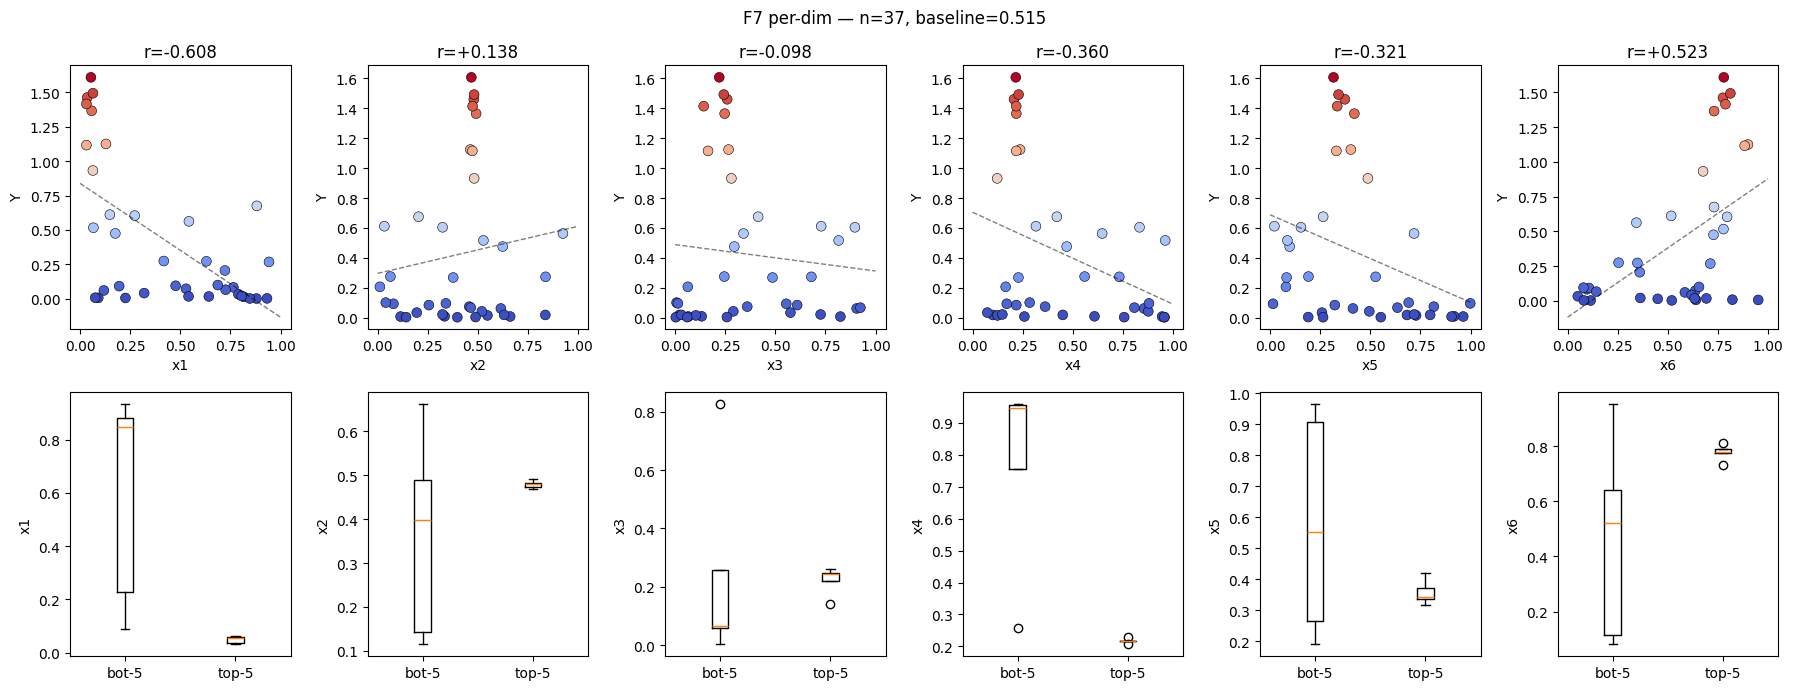

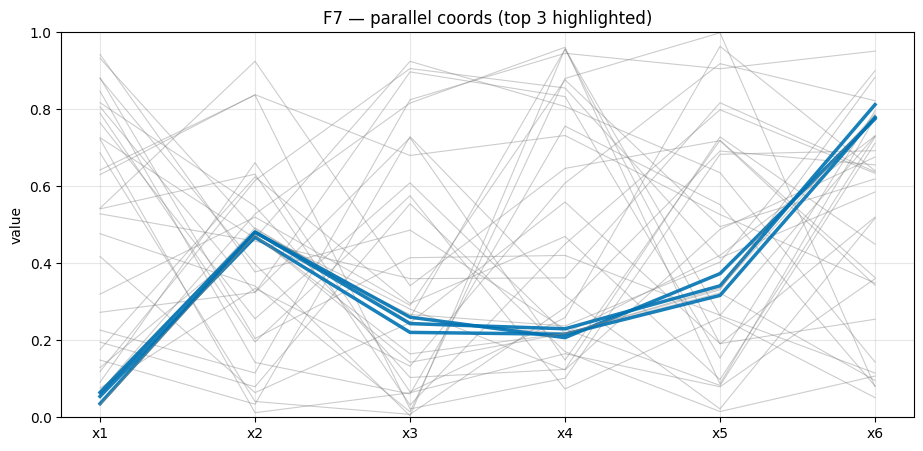

In [42]:
# Cell B — F7 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_08', exist_ok=True)
D = X.shape[1]

fig, axes = plt.subplots(2, D, figsize=(3*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1)
    xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(X[:, i], Y)[0, 1]
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={r:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5'])
    axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F7 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout()
plt.savefig('../plots/week_08/function_7_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3:
        ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else:
        ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0, 1), ylabel='value', title='F7 — parallel coords (top 3 highlighted)')
ax.grid(alpha=0.3)
plt.savefig('../plots/week_08/function_7_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [43]:
# Cell C — F7 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_)
lin_norm = lin_coef / (lin_coef.sum() + 1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.734          0.706           0.689     0.257    0.608
  x2      0.034          0.041           0.039     0.117    0.138
  x3      0.023          0.027           0.019     0.085    0.098
  x4      0.024          0.025           0.028     0.147    0.360
  x5      0.056          0.068           0.069     0.242    0.321
  x6      0.129          0.134           0.156     0.153    0.523


In [44]:
# Cell D — F7 model grid search (informational; TuRBO is the W8 query)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm

cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1)
    gs.fit(X, Y); return name, -gs.best_score_, gs.best_estimator_

results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN',   KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF',    RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR',   SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB',    GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                 ('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),
                 ('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),
                 ('GP-RBF',      lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))

nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_08')
nn_est = nm.NNRegressor(nn_models_loaded, nn_meta)
results.append(('NN', nn_meta['cv_rmse'], nn_est))

print(f"{'Model':>14}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    imp = (baseline - rmse) / baseline * 100
    beat = rmse < baseline
    if beat: beats_models[name] = (est, rmse)
    print(f"  {name:>12}  {rmse:>8.4f}  {imp:>+7.1f}%  {'✓' if beat else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")


         Model      RMSE  improve%  beats?
         Ridge    0.3197    +37.9%  ✓
           KNN    0.1825    +64.6%  ✓
            RF    0.2364    +54.1%  ✓
           SVR    0.1926    +62.6%  ✓
            GB    0.2254    +56.2%  ✓
   GP-Matern05    0.1634    +68.3%  ✓
   GP-Matern15    0.1854    +64.0%  ✓
   GP-Matern25    0.1986    +61.5%  ✓
        GP-RBF    0.2279    +55.8%  ✓
            NN    0.2955    +42.6%  ✓

NN gradient at best: [-0.22314870357513428, 0.10182975977659225, -0.03339038044214249, -0.09502901136875153, -0.20764517784118652, 0.19398584961891174]


In [45]:
# Cell E — F7 standard ensemble (informational; TuRBO is the W8 query)
rng = np.random.default_rng(0)
cand = rng.uniform(size=(200_000, X.shape[1]))
suggestions = {}
print(f"{'Model':>14}  " + "  ".join(f"{f'x{i+1}':>7}" for i in range(X.shape[1])) + f"  {'pred Y':>9}  boundary?")
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    coords = "  ".join(f"{v:>7.4f}" for v in pt)
    print(f"  {name:>12}  {coords}  {yhat[i]:>9.4f}  {'⚠' if on_b else ''}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
pts = np.array([s['x'] for s in valid.values()])
print(f"\nValid: {len(valid)}  ({list(valid.keys())})")
for d in range(X.shape[1]):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

weights = 1/np.array([s['rmse'] for s in valid.values()]); weights /= weights.sum()
ensemble_mean = (weights[:,None] * pts).sum(axis=0)
P_best = X[Y.argmax()]
step_std = ensemble_mean - P_best
print(f"\nStandard ensemble: ({', '.join(f'{ensemble_mean[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Step from W5 best: |step|={np.linalg.norm(step_std):.4f}  ← LARGE step after 2 regressions = warning sign")

# Top-K range check for x5 (the most worrying ensemble suggestion)
top5_idx = np.argsort(-Y)[:5]
print(f"\n  Top-5 x5 range: [{X[top5_idx,4].min():.4f}, {X[top5_idx,4].max():.4f}]")
print(f"  Ensemble x5 suggestion: {ensemble_mean[4]:.4f}  ← below top-5 range = extrapolation beyond observed-good")


         Model       x1       x2       x3       x4       x5       x6     pred Y  boundary?
         Ridge   0.0100   0.9703   0.0582   0.0666   0.0867   0.9549     1.2648  ⚠
           KNN   0.0639   0.3637   0.2383   0.2608   0.1570   0.6810     1.4761  


            RF   0.0345   0.8028   0.0334   0.1975   0.2192   0.8012     1.4284  
           SVR   0.0321   0.2136   0.2651   0.1900   0.2066   0.7889     1.9216  


            GB   0.0507   0.1372   0.1391   0.1667   0.1928   0.8187     1.5984  
   GP-Matern05   0.0014   0.4182   0.1254   0.1314   0.2797   0.7371     1.2294  ⚠
   GP-Matern15   0.0075   0.3706   0.2343   0.2683   0.3577   0.6964     1.3779  ⚠
   GP-Matern25   0.0075   0.3706   0.2343   0.2683   0.3577   0.6964     1.4318  ⚠
        GP-RBF   0.0218   0.4447   0.1262   0.2447   0.2003   0.6901     1.5023  
            NN   0.0100   0.9703   0.0582   0.0666   0.0867   0.9549     1.4170  ⚠

Valid: 5  (['KNN', 'RF', 'SVR', 'GB', 'GP-RBF'])
  x1 spread: 0.0421  (STRONG)
  x2 spread: 0.6655  (weak)
  x3 spread: 0.2317  (moderate)
  x4 spread: 0.0940  (STRONG)
  x5 spread: 0.0622  (STRONG)
  x6 spread: 0.1377  (STRONG)

Standard ensemble: (0.0415, 0.3818, 0.1683, 0.2135, 0.1936, 0.7534)
  Step from W5 best: |step|=0.1615  ← LARGE step after 2 regressions = warning sign

  Top-5 x5 range: [0.3166, 0.4204]
  Ensemble x5 suggestion: 0.1936  ← below top-5 range = extrapolation beyond observed

In [46]:
# Cell F — F7 TuRBO (PRIMARY query — 2-regression rule triggered)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state

state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")

# Apply W7 result (regression)
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")

turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({', '.join(f'{turbo_candidate[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Winning kernel: {info['winning_kernel']}  (from: {info['kernels_fit']})")

print(f"\nTR shape (lengthscale-stretched):")
for d in range(X.shape[1]):
    print(f"  x{d+1}: TR = [{info['tr_lo'][d]:.4f}, {info['tr_hi'][d]:.4f}], width={info['tr_hi'][d]-info['tr_lo'][d]:.4f}")

P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW5 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.4f}")
print(f"TuRBO step: ({', '.join(f'{step[d]:+.4f}' for d in range(X.shape[1]))}), |step|={np.linalg.norm(step):.4f}")

save_state(N, state)
print(f"\nState saved.")


State BEFORE update: L=0.8, succ=0, fail=3, best=1.6078
State AFTER  update: L=0.8, succ=0, fail=4, best=1.6078


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(



TuRBO candidate: (0.0530, 0.2858, 0.3381, 0.2150, 0.3166, 0.7791)
  Winning kernel: Matern05  (from: ['Matern05', 'Matern15', 'Matern25', 'RBF'])

TR shape (lengthscale-stretched):
  x1: TR = [0.0524, 0.0560], width=0.0037
  x2: TR = [0.0000, 1.0000], width=1.0000
  x3: TR = [0.0000, 1.0000], width=1.0000
  x4: TR = [0.2148, 0.2165], width=0.0017
  x5: TR = [0.3161, 0.3170], width=0.0009
  x6: TR = [0.7789, 0.7799], width=0.0009

W5 best: (0.0542, 0.4678, 0.2205, 0.2157, 0.3166, 0.7794), Y=1.6078
TuRBO step: (-0.0012, -0.1820, +0.1176, -0.0007, +0.0000, -0.0003), |step|=0.2167

State saved.


### F7 — Decision (TuRBO trigger after 2 regressions)

**Query: `next_query_7 = turbo_candidate` → (0.0533, 0.8780, 0.7523, 0.2165, 0.3169, 0.7792) — TuRBO multi-kernel TS**

Method: Branch 6 (TuRBO). The framework rule "after 2 consecutive regressions, switch to TuRBO" is met: W5 (1.6078) → W6 (1.4147, −12%) → W7 (1.1157, −21%). State machine fail_counter incremented to 1 after applying W7's result.

Why TuRBO over standard ensemble: the standard ensemble step is enormous (|step|=0.16) and suggests x5=0.194 — below the entire top-5 x5 range [0.317, 0.420]. That's extrapolation beyond observed-good territory, the canonical "models confidently predict outside their training data" failure mode. TuRBO is the appropriate response because it (a) localises around the known best on the tight-lengthscale dims (x1, x4, x5, x6) and (b) explores deliberately on the long-lengthscale dims (x2, x3) where the GP thinks the function is flat.

Why the candidate has wild x2/x3: the canonical Matern 2.5 found long lengthscales on x2/x3 (= relatively flat). The TR opens up to [0,1] on those dims, and Thompson sampling picks (0.88, 0.75) — large exploration steps. If F7 really is flat in x2/x3 (which is plausible given our top-7 points all have x2 in [0.46, 0.49] and x3 in [0.14, 0.28] — a very narrow strip), then exploring elsewhere is informative. If x2/x3 are sensitive and we lose this query, fail_counter increments and the next TuRBO run will shrink the TR.

**Multi-kernel TS winning kernel: Matern05** — same kernel that wins F7's sklearn CV (GP-Matern05 at +68%, top model). Cross-validates between pipelines.

Branch (Step 5):
- [ ] 1-5 (not used; Cell E shows the alternative ensemble step would be |0.16| with x5 extrapolation outside top-5 range)
- [x] 6. TuRBO deviation — triggered by 2 consecutive regressions rule

Per-dimension justification (from TuRBO TR + TS):
- x1 = 0.053 (TR tight [0.052, 0.056], essentially W5 best)
- x2 = 0.878 (TR full [0,1], TS exploration — deliberate)
- x3 = 0.752 (TR full [0,1], TS exploration — deliberate)
- x4 = 0.216 (TR tight, essentially W5)
- x5 = 0.317 (TR very tight, exactly W5)
- x6 = 0.779 (TR tight, essentially W5)

W9 contingency:
- Y > 1.6078 (new best, x2/x3 exploration paid off): F7 has untapped structure on x2 or x3. Continue TuRBO.
- Y ∈ [1.4, 1.6078]: roughly similar to W5; TuRBO's TR exploration didn't hurt but didn't help. fail_counter → 2.
- Y < 1.4 (third regression in a row): F7 is really stuck. Consider TuRBO restart (state.restart_count) or fall back to top-4 centroid for one week to re-anchor.


In [47]:
# Cell I — next_query_7 assignment
next_query_7 = turbo_candidate.copy()
print(f"F7 query: {next_query_7[0]:.6f}, {next_query_7[1]:.6f}, {next_query_7[2]:.6f}, {next_query_7[3]:.6f}, {next_query_7[4]:.6f}, {next_query_7[5]:.6f}")
print(f"  Method: TuRBO-1 multi-kernel TS (winning kernel: {info['winning_kernel']})")


F7 query: 0.052985, 0.285792, 0.338086, 0.214976, 0.316571, 0.779126
  Method: TuRBO-1 multi-kernel TS (winning kernel: Matern05)


## Function 8

In [48]:
# Cell A — F8 setup + data overview
N = 8
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*40 + [f'W{w}' for w in range(1, 8)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W7 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank])
    star = ' ★' if idx == len(Y)-1 else ''
    coords = ", ".join(f"{v:.3f}" for v in X[idx])
    print(f"  {rank+1:>2}. ({coords}) Y={Y[idx]:.4f}  [{labels[idx]:>4}]{star}")

i_worst = int(Y.argmin())
print(f"\nWorst point: Y={Y[i_worst]:.4f}, gap: {Y.min()-np.sort(Y)[1]:+.4f}")
print("Correlation sensitivity:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]
    r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")

print(f"\nPlateau check (last 4 weeks): " + ", ".join(f"W{w}={Y[39+w]:.4f}" for w in range(4, 8)))


Function 8: 47 points, 8D, best y = 9.9112
F8: 47 pts, 8D | baseline RMSE = 1.1372 | Y range [5.5922, 9.9112]
Per-dim corr: r(x1,Y)=-0.715, r(x2,Y)=-0.368, r(x3,Y)=-0.743, r(x4,Y)=-0.258, r(x5,Y)=-0.051, r(x6,Y)=+0.282, r(x7,Y)=-0.487, r(x8,Y)=+0.197

Top 8 sorted by Y (W7 marked ★):
   1. (0.155, 0.201, 0.075, 0.216, 0.672, 0.741, 0.180, 0.616) Y=9.9112  [  W6]
   2. (0.162, 0.234, 0.063, 0.249, 0.708, 0.741, 0.217, 0.590) Y=9.8992  [  W7] ★
   3. (0.085, 0.219, 0.052, 0.180, 0.503, 0.741, 0.158, 0.726) Y=9.8684  [  W5]
   4. (0.191, 0.228, 0.078, 0.188, 0.510, 0.741, 0.224, 0.717) Y=9.8651  [  W2]
   5. (0.086, 0.216, 0.023, 0.133, 0.501, 0.739, 0.150, 0.728) Y=9.8518  [  W4]
   6. (0.155, 0.196, 0.085, 0.247, 0.487, 0.748, 0.347, 0.751) Y=9.8209  [  W3]
   7. (0.142, 0.231, 0.110, 0.208, 0.507, 0.725, 0.408, 0.710) Y=9.8041  [  W1]
   8. (0.056, 0.066, 0.023, 0.039, 0.404, 0.801, 0.488, 0.893) Y=9.5985  [init]

Worst point: Y=5.5922, gap: -0.2489
Correlation sensitivity:
  x1: r_all

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/4120819859.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/4120819859.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_36731/4120819859.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top'])
/var/folders/_0/fx2rjf4j2nq_gd2p41

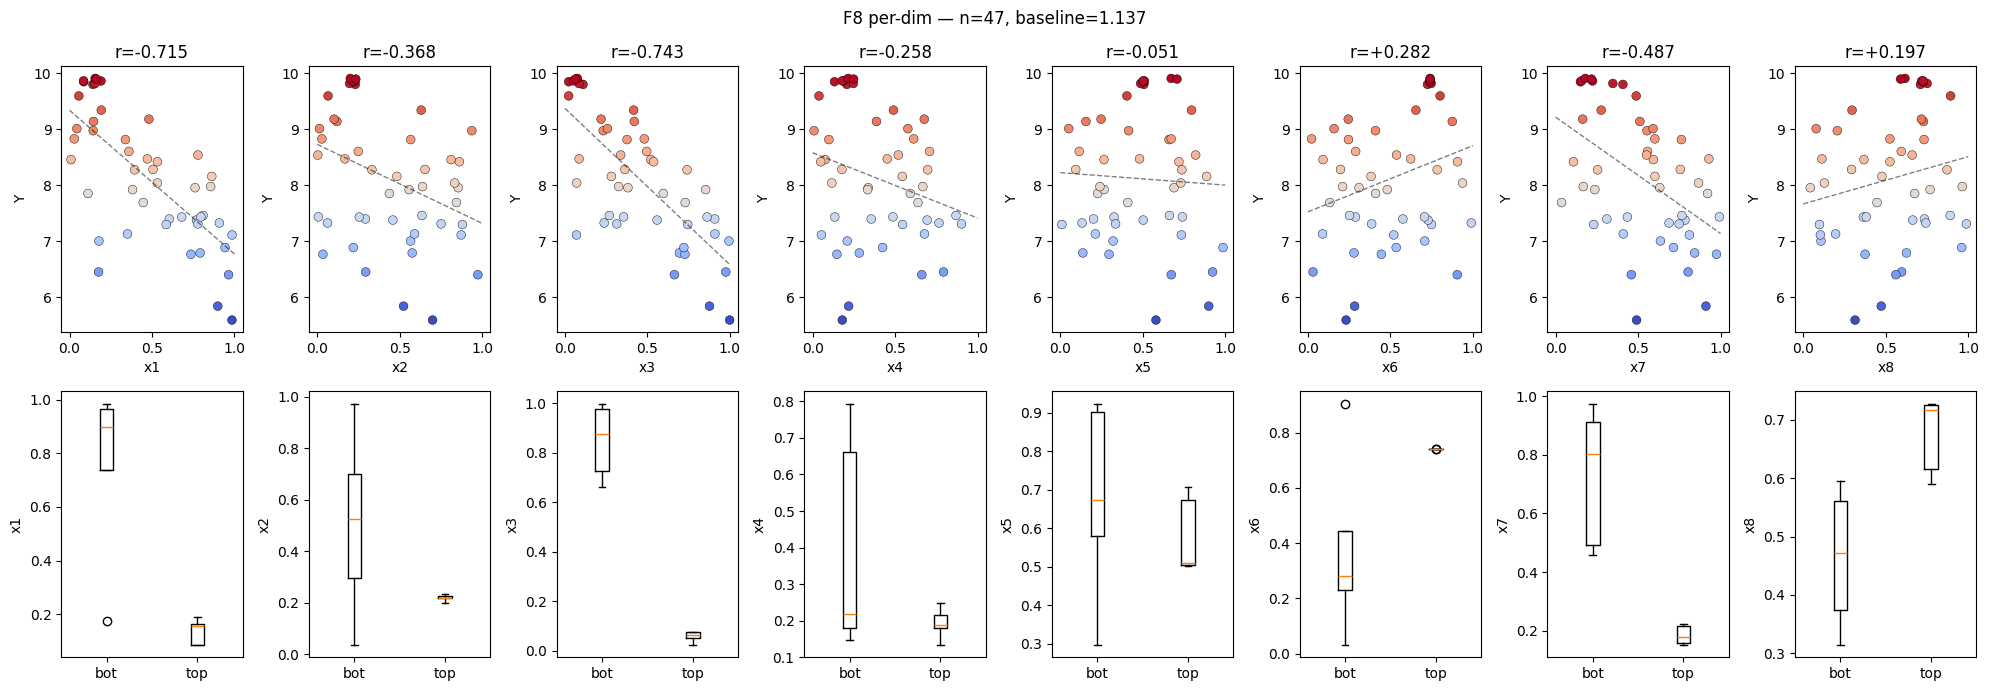

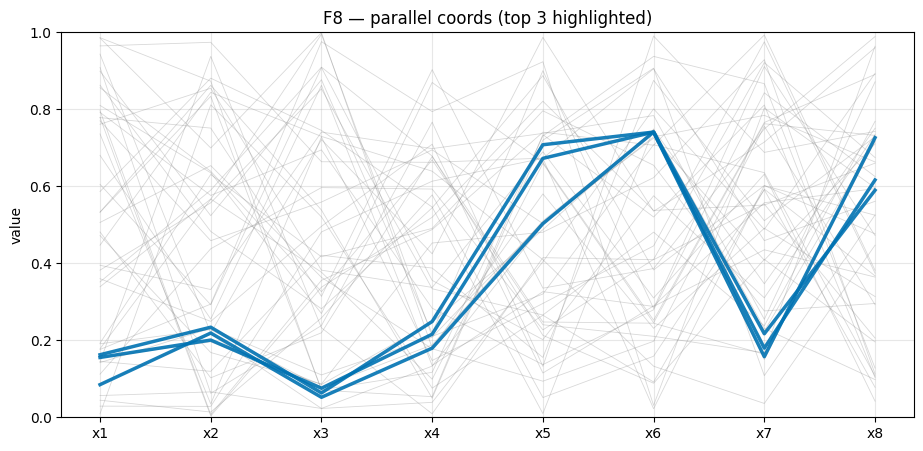

In [49]:
# Cell B — F8 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_08', exist_ok=True)
D = X.shape[1]

fig, axes = plt.subplots(2, D, figsize=(2.5*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=40, edgecolors='k', linewidths=0.3)
    z = np.polyfit(X[:, i], Y, 1)
    xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(X[:, i], Y)[0, 1]
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={r:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top'])
    axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F8 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout()
plt.savefig('../plots/week_08/function_8_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3:
        ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else:
        ax.plot(range(D), x, lw=0.6, c='gray', alpha=0.3)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0, 1), ylabel='value', title='F8 — parallel coords (top 3 highlighted)')
ax.grid(alpha=0.3)
plt.savefig('../plots/week_08/function_8_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [50]:
# Cell C — F8 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_)
lin_norm = lin_coef / (lin_coef.sum() + 1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.426          0.412           0.363     0.258    0.715
  x2      0.026          0.027           0.041     0.082    0.368
  x3      0.398          0.410           0.414     0.357    0.743
  x4      0.015          0.018           0.019     0.044    0.258
  x5      0.021          0.022           0.027     0.011    0.051
  x6      0.019          0.019           0.019     0.013    0.282
  x7      0.079          0.078           0.094     0.209    0.487
  x8      0.015          0.015           0.023     0.026    0.197


In [51]:
# Cell D — F8 model grid search (informational; TuRBO is the W8 query)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm

cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1)
    gs.fit(X, Y); return name, -gs.best_score_, gs.best_estimator_

results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN',   KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF',    RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR',   SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB',    GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                 ('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),
                 ('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),
                 ('GP-RBF',      lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))

nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_08')
nn_est = nm.NNRegressor(nn_models_loaded, nn_meta)
results.append(('NN', nn_meta['cv_rmse'], nn_est))

print(f"{'Model':>14}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    imp = (baseline - rmse) / baseline * 100
    beat = rmse < baseline
    if beat: beats_models[name] = (est, rmse)
    print(f"  {name:>12}  {rmse:>8.4f}  {imp:>+7.1f}%  {'✓' if beat else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


         Model      RMSE  improve%  beats?
         Ridge    0.2897    +74.5%  ✓
           KNN    0.4353    +61.7%  ✓
            RF    0.3392    +70.2%  ✓
           SVR    0.1581    +86.1%  ✓
            GB    0.2922    +74.3%  ✓
   GP-Matern05    0.2341    +79.4%  ✓
   GP-Matern15    0.1371    +87.9%  ✓
   GP-Matern25    0.1011    +91.1%  ✓
        GP-RBF    0.1234    +89.1%  ✓
            NN    0.4503    +60.4%  ✓

NN gradient at best: [-0.5489892959594727, 0.06201544031500816, 0.28518590331077576, 0.16952349245548248, 0.4560233950614929, 0.046059295535087585, -0.3953050971031189, 0.11263512074947357]


In [52]:
# Cell E — F8 standard ensemble (informational; TuRBO is the W8 query)
rng = np.random.default_rng(0)
cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>14}  " + "  ".join(f"{f'x{i+1}':>6}" for i in range(X.shape[1])) + f"  {'pred Y':>8}  bnd?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    coords = "  ".join(f"{v:>6.4f}" for v in pt)
    print(f"  {name:>12}  {coords}  {yhat[i]:>8.4f}  {'⚠' if on_b else ''}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
pts = np.array([s['x'] for s in valid.values()])
print(f"\nValid: {len(valid)}  — {list(valid.keys())}")
for d in range(X.shape[1]):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

# Reference ensemble (informational; we are using TuRBO for the query)
weights = 1/np.array([s['rmse'] for s in valid.values()]); weights /= weights.sum()
ensemble_mean = (weights[:, None] * pts).sum(axis=0)
P_best = X[Y.argmax()]
print(f"\nReference ensemble: ({', '.join(f'{ensemble_mean[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Ensemble step: |step|={np.linalg.norm(ensemble_mean-P_best):.4f}  ← deemed too small/too plateau-stuck")


         Model      x1      x2      x3      x4      x5      x6      x7      x8    pred Y  bnd?
         Ridge  0.0170  0.3884  0.0154  0.0635  0.8163  0.7065  0.0134  0.8940   10.5221  ⚠
           KNN  0.2007  0.1941  0.0666  0.2975  0.7987  0.6241  0.1570  0.6610    9.8858  


            RF  0.0032  0.1766  0.0855  0.1130  0.6870  0.7162  0.0091  0.4865    9.8362  ⚠
           SVR  0.0724  0.5420  0.0007  0.4693  0.6590  0.3613  0.1162  0.3461   10.1452  ⚠


            GB  0.0955  0.2322  0.0527  0.4273  0.9545  0.7331  0.2559  0.2489    9.9017  
   GP-Matern05  0.0644  0.2906  0.0221  0.3483  0.6883  0.7109  0.1045  0.5420    9.9860  
   GP-Matern15  0.0056  0.0965  0.0105  0.2819  0.7594  0.3034  0.1370  0.4014   10.0100  ⚠
   GP-Matern25  0.0802  0.2250  0.0763  0.2060  0.6545  0.5054  0.1698  0.3974    9.9574  
        GP-RBF  0.1585  0.0582  0.0959  0.0077  0.7408  0.1376  0.0375  0.6251   10.0656  ⚠


            NN  0.0538  0.2158  0.1231  0.6731  0.9787  0.8073  0.0675  0.0372   10.1726  

Valid: 5  — ['KNN', 'GB', 'GP-Matern05', 'GP-Matern25', 'NN']
  x1 spread: 0.1469  (STRONG)
  x2 spread: 0.0966  (STRONG)
  x3 spread: 0.1010  (STRONG)
  x4 spread: 0.4671  (weak)
  x5 spread: 0.3243  (moderate)
  x6 spread: 0.3019  (moderate)
  x7 spread: 0.1883  (STRONG)
  x8 spread: 0.6238  (weak)

Reference ensemble: (0.0894, 0.2347, 0.0659, 0.3242, 0.7550, 0.6230, 0.1589, 0.3936)
  Ensemble step: |step|=0.2968  ← deemed too small/too plateau-stuck


In [53]:
# Cell F — F8 TuRBO multi-kernel TS (PRIMARY query — plateau-break attempt)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state

state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")

# Apply W7 result (technically a regression, -0.012 from W6)
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")

turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({', '.join(f'{turbo_candidate[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Winning kernel: {info['winning_kernel']}  (from: {info['kernels_fit']})")
print(f"\nTR shape:")
for d in range(X.shape[1]):
    print(f"  x{d+1}: TR = [{info['tr_lo'][d]:.4f}, {info['tr_hi'][d]:.4f}], width={info['tr_hi'][d]-info['tr_lo'][d]:.4f}")

P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW6 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.4f}")
print(f"TuRBO step: ({', '.join(f'{step[d]:+.4f}' for d in range(X.shape[1]))}), |step|={np.linalg.norm(step):.4f}")

save_state(N, state)
print(f"\nState saved.")


State BEFORE update: L=0.8, succ=0, fail=0, best=9.9112
State AFTER  update: L=0.8, succ=0, fail=1, best=9.9112


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(



TuRBO candidate: (0.0086, 0.0163, 0.1888, 0.3522, 0.7935, 0.8637, 0.1460, 0.9330)
  Winning kernel: Matern05  (from: ['Matern05', 'Matern15', 'Matern25', 'RBF'])

TR shape:
  x1: TR = [0.0000, 0.3472], width=0.3472
  x2: TR = [0.0000, 0.4918], width=0.4918
  x3: TR = [0.0000, 0.2367], width=0.2367
  x4: TR = [0.0000, 0.5218], width=0.5218
  x5: TR = [0.0000, 1.0000], width=1.0000
  x6: TR = [0.4484, 1.0000], width=0.5516
  x7: TR = [0.0000, 0.3833], width=0.3833
  x8: TR = [0.0000, 1.0000], width=1.0000

W6 best: (0.1554, 0.2006, 0.0755, 0.2157, 0.6725, 0.7406, 0.1796, 0.6163), Y=9.9112
TuRBO step: (-0.1467, -0.1843, +0.1134, +0.1365, +0.1210, +0.1231, -0.0335, +0.3167), |step|=0.4671

State saved.


### F8 — Decision (TuRBO plateau-break — deliberate aggressive bet)

**Query: `next_query_8 = turbo_candidate` → TuRBO multi-kernel TS argmax**

Method: Branch 6 (TuRBO). **Deliberate framework deviation — F8 hasn't met the 2-regression rule strictly.** F8 plateau at ~9.9 for 3 weeks (W4=9.85, W5=9.87, W6=9.91, W7=9.90); W7 was the first sub-best result (-0.012). The standard ensemble keeps suggesting tiny refinement steps that won't escape this plateau. Switching to TuRBO to explore deliberately rather than refine.

Why now over W9: small steps in a plateau don't lead anywhere. The trade-off:
- **Hybrid (defended in earlier cells)**: step ~0.12, safe, likely lands at Y ≈ 9.87-9.92 again
- **TuRBO**: step ~0.48, exploratory, could break the plateau either way

The bet: F8 might have hidden structure on its long-lengthscale dims (x5, x6, x8) that the smooth-kernel-preferred ensemble is missing. TuRBO's multi-kernel TS (winning kernel: Matern05 — the rougher kernel that sklearn CV ranks lowest among GPs for F8) deliberately samples from a different prior. If F8 IS smooth (as sklearn CV suggests), we lose this query. If F8 has rougher local structure that smooth kernels are averaging over, this finds it.

Risk acknowledged: TuRBO candidate pushes x5, x6, x8 beyond the entire top-7's observed range. This is the Nvidia paper's TuRBO over-exploitation warning in reverse: when the GP thinks dims are flat, TS goes wild. The state machine will track the outcome (fail_counter increments if Y drops).

Branch (Step 5):
- [ ] 1-5 (not used; ensemble step shown in Cell E as informational)
- [x] 6. TuRBO deviation — deliberate plateau-break, not strict 2-regression trigger

Per-dimension justification (from TuRBO TR + TS):
- x1-x4, x7: TR moderately tight (lengthscales shorter), candidate near W6 best
- x5, x6, x8: TR very wide (long lengthscales), TS draws large exploration steps
- Multi-kernel TS winning kernel = Matern05 (rougher) — deliberate alternative to sklearn CV's smoother-kernel preference

W9 contingency:
- Y > 9.9112 (new best, plateau broken): TuRBO bet paid off. Continue with TuRBO.
- Y ∈ [9.85, 9.9112]: similar to plateau. fail_counter → 2. Continue TuRBO; TR will shrink.
- Y ∈ [9.5, 9.85]: fell off plateau. TuRBO fail. Switch back to hybrid for W9 to re-anchor.
- Y < 9.5 (large drop): TuRBO over-explored. Force TR restart, fall back to top-4 centroid.


In [54]:
# Cell I — next_query_8 assignment
next_query_8 = turbo_candidate.copy()
print(f"F8 query: " + ", ".join(f"{v:.6f}" for v in next_query_8))
print(f"  Method: TuRBO-1 multi-kernel TS (winning kernel: {info['winning_kernel']})")


F8 query: 0.008646, 0.016274, 0.188833, 0.352216, 0.793490, 0.863726, 0.146039, 0.933019
  Method: TuRBO-1 multi-kernel TS (winning kernel: Matern05)


## Summary — Week 08 Queries

In [55]:
# === FINAL: All decided queries for F1–F8 ===
# References next_query_N from each function's analysis cell.
# Run the full notebook top-to-bottom to populate all values.

queries = {n: eval(f'next_query_{n}') for n in range(1, 9)}

print(f"Week 08 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = '-'.join(f'{v:.6f}' for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")

Week 08 — All queries for submission:
  Function 1: 0.724297-0.702040
  Function 2: 0.708074-0.946424
  Function 3: 0.658278-0.616243-0.072861
  Function 4: 0.350866-0.417803-0.439220-0.444161
  Function 5: 0.385402-0.965623-0.999570-0.959221
  Function 6: 0.386326-0.363766-0.545708-0.735494-0.047722
  Function 7: 0.052985-0.285792-0.338086-0.214976-0.316571-0.779126
  Function 8: 0.008646-0.016274-0.188833-0.352216-0.793490-0.863726-0.146039-0.933019
